In this notebook we test Vanguri et al. architecture on the I3LUNG data. 


# Set-up

In [1]:
import pandas as pd
import os
from lung_helpers import train, get_training_data, train_standard_split, hyperparameter_search

In [2]:
if not 'summary_dfs' in locals():
    print ("init summary_dfs")
    summary_dfs = {}

init summary_dfs


In [3]:
DATA_DIR = "../../data"
RESULTS_DIR = "./results"

os.makedirs(RESULTS_DIR, exist_ok=True)

In [4]:
df_outcomes = pd.read_csv(f"{DATA_DIR}/outcomes.csv")
df_outcomes = df_outcomes.rename(columns={'Subject': 'main_index'}).set_index('main_index')

# Find coumns with 2075 label non-null
outcome_cols_complete = []
for col in df_outcomes.columns:
    n_valid = df_outcomes[col].notna().sum()
    print(f"{col}: {n_valid} non-null")
    if n_valid == 2075:
        outcome_cols_complete.append(col)


DEATH EVENT: 2075 non-null
PROGRESSION EVENT: 2070 non-null
THERAPY END EVENT: 2075 non-null
BEST RESPONSE: 2068 non-null
IO LINE: 2075 non-null
IO IOCHT: 2075 non-null
HISTOLOGY SQUAMOUS: 2052 non-null
HISTOLOGY ADENOCARCINOMA: 2052 non-null
ORR: 2068 non-null
DCR: 2068 non-null
CBR: 2066 non-null
PFS MONTHS: 2066 non-null
OS MONTHS: 2074 non-null
TTF MONTHS: 2073 non-null
OS_6: 1972 non-null
OS_24: 1699 non-null


In [5]:
# complete cohort
df_clinical_full = pd.read_csv(f"{DATA_DIR}/rwd_processed.csv")
df_clinical_full = df_clinical_full.rename(columns={'Subject': 'main_index'})

# Cohort2 (IO LINE == 1)
df_rwd = pd.read_csv(f"{DATA_DIR}/rwd.csv")
df_rwd_cohort2 = df_rwd[df_rwd['IO LINE'] == 1].copy()

cohorts = {
    'cohort23': {
        'subjects': df_clinical_full['main_index'].values,
        'split_source': df_clinical_full
    },
    'cohort2': {
        'subjects': df_rwd_cohort2['Subject'].values,
        'split_source': df_rwd_cohort2.rename(columns={'Subject': 'main_index'})
    }
}

all_splits = {}

for cohort_name, cohort_info in cohorts.items():
    print(f"\n{'='*50}")
    print(f"Processing {cohort_name}")
    print(f"{'='*50}")
    
    # filter df_clinical_full for the subjects in the cohort
    cohort_subjects = cohort_info['subjects']
    df_clinical = df_clinical_full[df_clinical_full['main_index'].isin(cohort_subjects)].copy()
    
    # extract splits
    split_df = cohort_info['split_source']
    train_df = split_df[split_df['SET'] == 'TRAIN']
    test_df = split_df[split_df['SET'] == 'TEST']
    ext_val_df = split_df[split_df['SET'] == 'EXVAL']
    
    train_px = train_df['main_index'].values
    test_px = test_df['main_index'].values
    ext_val_px = ext_val_df['main_index'].values
    
    print(f"=== INITIAL SPLIT {cohort_name} ===")
    print(f"Train: {len(train_px)}, Test: {len(test_px)}, ExtVal: {len(ext_val_px)}")
    
    # extract predefined folds (exclude UOC from training centers)
    predefined_folds = train_df[train_df['CENTER'] != 'UOC'][['main_index', 'CENTER']].rename(columns={'CENTER': 'fold'})
    predefined_folds = predefined_folds.set_index('main_index')
    
    print(f"Train Centers (per CV): {predefined_folds['fold'].unique()}")
    print(f"Patients for center:\n{predefined_folds['fold'].value_counts()}")
    
    # prepare clinical dataframe
    df_clinical = df_clinical.set_index('main_index')
    df_clinical = df_clinical.drop(columns=['CENTER', 'SET'], errors='ignore')
    
    # save for later use
    all_splits[cohort_name] = {
        'df_clinical': df_clinical,
        'train_px': train_px,
        'test_px': test_px,
        'ext_val_px': ext_val_px,
        'predefined_folds': predefined_folds
    }


Processing cohort23
=== INITIAL SPLIT cohort23 ===
Train: 1550, Test: 274, ExtVal: 251
Train Centers (per CV): ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
Patients for center:
fold
INT     582
GHD     365
SZMC    232
MH      196
VHIO    175
Name: count, dtype: int64

Processing cohort2
=== INITIAL SPLIT cohort2 ===
Train: 1046, Test: 181, ExtVal: 210
Train Centers (per CV): ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
Patients for center:
fold
INT     386
GHD     231
SZMC    193
MH      164
VHIO     72
Name: count, dtype: int64


In [6]:
df_pyrad = pd.read_csv(f"{DATA_DIR}/pyradiomics.csv")
df_pyrad = df_pyrad.rename(columns={'Subject': 'main_index'})

print(f"total patients: {len(df_pyrad)}")

# Set index e drop colonne
df_pyrad = df_pyrad.set_index('main_index')
df_pyrad = df_pyrad.drop(columns=['CENTER', 'SET'], errors='ignore')

print(f"pyradiomics features: {len(df_pyrad.columns)}")

total patients: 877
pyradiomics features: 128


In [7]:
df_fmrad = pd.read_csv(f"{DATA_DIR}/fmrad.csv")
df_fmrad = df_fmrad.rename(columns={'Subject': 'main_index'})

print(f"total patients: {len(df_fmrad)}")
# Set index e drop columns
df_fmrad = df_fmrad.set_index('main_index')
df_fmrad = df_fmrad.drop(columns=['CENTER', 'SET'], errors='ignore')

print(f"fmradiomics features: {len(df_fmrad.columns)}")

total patients: 896
fmradiomics features: 4096


In [8]:
df_pathology = pd.read_csv(f"{DATA_DIR}/digital_pathology_processed.csv")  
df_pathology = df_pathology.rename(columns={'Subject': 'main_index'})  

print(f"total patients: {len(df_pathology)}")

# Set index e drop columns
df_pathology = df_pathology.set_index('main_index')
df_pathology = df_pathology.drop(columns=['CENTER', 'SET'], errors='ignore')  

print(f"pathology features: {len(df_pathology.columns)}")

total patients: 846
pathology features: 768


In [9]:
df_genomics = pd.read_csv(f"{DATA_DIR}/genomics_processed.csv") 
df_genomics = df_genomics.rename(columns={'Subject': 'main_index'})  

print(f"total patients: {len(df_genomics)}")

# Set index e drop columns
df_genomics = df_genomics.set_index('main_index')
df_genomics = df_genomics.drop(columns=['CENTER', 'SET'], errors='ignore')

print(f"genomics features: {len(df_genomics.columns)}")

total patients: 1705
genomics features: 4


In [10]:
df_outcomes = pd.read_csv(f"{DATA_DIR}/outcomes.csv")
df_outcomes = df_outcomes.rename(columns={'Subject': 'main_index'})
df_outcomes = df_outcomes.set_index('main_index')
df_outcomes = df_outcomes[~df_outcomes.index.duplicated()]
print("total patients:", df_outcomes.index.nunique())
print(f"total outcomes: {len(df_outcomes.columns)}")

total patients: 2075
total outcomes: 16


# Hyperparam search

default hyperparam from original paper

In [11]:
# for multimodal models, attention gate
model_params = {'epochs':125, 'lr':0.01, 'alpha':0.001, 'beta':0.0, 'cross_modality_enabled':False}
# for unimodal models, no attention gate
model_params_gate_off = {'epochs':125, 'lr':0.01, 'alpha':0.001, 'beta':0.0, 'cross_modality_enabled':False, 'attention_gate_enabled':False}

hyperparam grid

In [12]:
hyperparam_grid = {
    'epochs': [100, 125, 150],
    'lr': [0.001, 0.01, 0.1],
    'alpha': [0.0001, 0.001, 0.01],  # L2 weight
    'beta': [0.0, 0.001, 0.01]       # AR2 weight
}

We perform hyperparameter search following the Vanguri method. We split the training data by reserving 10% as a validation set and using the remaining 90% for training. Each combination of hyperparameters is trained on the 90% training subset and evaluated on the 10% validation subset. We select the best-performing hyperparameter set based on the highest AUC score on the validation set, where "best performing" is defined as the configuration that achieves the highest AUC with a confidence interval that does not overlap with those of other configurations. We selected the hyperparameters on the largest cohort of patients with the most modalities.

In [13]:
# Prepare data for cohort23, OS_6
cohort_name = 'cohort23'
outcome_col = 'OS_6'

df_clinical_clean = all_splits[cohort_name]['df_clinical'].copy()
train_px = all_splits[cohort_name]['train_px']

# Filtra solo train set
df_clinical_train = df_clinical_clean.loc[train_px]

cohort_subjects = df_clinical_train.index
df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()

df_dyam = df_clinical_train.copy()
df_dyam['label'] = df_outcomes[outcome_col]
df_dyam = df_dyam.dropna(subset=['label'])

X_clin = df_dyam.drop(columns=['label']).fillna(0)
X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)

modality_mask = pd.DataFrame({
    'clinical': 1,
    'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
    'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
    'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
}, index=df_dyam.index)

df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)

# L1 filter
df_rad_for_filter = X_rad.reset_index()
df_rad_for_filter['job_tag'] = 'filtered-radiomics'
df_rad_for_filter['site'] = 'PC'
df_rad_for_filter['lesion_index'] = 1

dfs_filters = {
    1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
}

# Run hyperparameter search
best_params, search_results = hyperparameter_search(
    [X_clin, X_rad, X_path, X_gen],
    modality_mask, 
    df_out,
    dfs_filters,
    hyperparam_grid
)

# Save results
search_results.to_csv('results/hyperparam_search_results_cohort23_OS_6.csv', index=False)

print(f"\nUsing best parameters for all models: {best_params}")

Testing 81 combinations
Train: 1325, Validation: 148

Train samples: 1325
Test samples: 148
Applying L1 filter on modality position 1
Selected 17 outlier-stable features
Training 100 epochs with 6 batches
Final output - min: -0.9600, max: 0.8659, mean: 0.0176
Training mode - mu: -0.0101, std: 0.3353
Eval mode - using mu: -0.0101, std: 0.3353
Eval mode - using mu: -0.0101, std: 0.3353

Test AUC: 0.648 (95% CI: 0.548-0.747)
epochs=100, lr=0.001, alpha=0.0001, beta=0.0 -> Val AUC: 0.658 (95% CI: 0.629-0.688)
  -> New best (no CI overlap)
Train samples: 1325
Test samples: 148
Applying L1 filter on modality position 1
Selected 17 outlier-stable features
Training 100 epochs with 6 batches
Final output - min: -0.9657, max: 0.9023, mean: 0.0462
Training mode - mu: 0.0366, std: 0.3271
Eval mode - using mu: 0.0366, std: 0.3271
Eval mode - using mu: 0.0366, std: 0.3271

Test AUC: 0.649 (95% CI: 0.554-0.744)
epochs=100, lr=0.001, alpha=0.0001, beta=0.001 -> Val AUC: 0.672 (95% CI: 0.644-0.701)
  -

# Unimodal clinical

cross validation unimodal

In [14]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training models for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        X_dyam = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_dyam.isna().sum().sum()}")
        
        modality_mask_single = pd.DataFrame({
            'clinical': X_dyam.notna().any(axis=1).astype(int)
        }, index=X_dyam.index)
        print(f"Modality mask created with {modality_mask_single['clinical'].sum()} samples having clinical data")
        
        X_dyam_filled = X_dyam.fillna(0)
        print(f"After filling missing values: {X_dyam_filled.isna().sum().sum()} missing values")
        
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        common_index = X_dyam_filled.index & modality_mask_single.index & df_out.index
        X_dyam_filled = X_dyam_filled.loc[common_index]
        modality_mask_single = modality_mask_single.loc[common_index]
        df_out = df_out.loc[common_index]
        
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        cv_index = predefined_folds_aligned.index
        X_dyam_cv = X_dyam_filled.loc[cv_index]
        modality_mask_cv = modality_mask_single.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        summary_dfs[f'{cohort_name}_Clinical_{outcome_col}'], _ = train(
            modality_list_in=[X_dyam_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter={},
            model_params=model_params_gate_off,
            predefined_folds=predefined_folds_aligned
        )
        
        summary_dfs[f'{cohort_name}_Clinical_{outcome_col}'].to_csv(
            f'results/cv_rwd_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training models for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Processing outcome: OS_24, initial samples: 2075
After dropping missing labels: 1699 samples
Initial missing values in features: 0
Modality mask created with 1699 samples having clinical data
After filling missing values: 0 missing values
Predefined folds after alignment: 1283 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1283 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 362 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (921 samples)
Fold INT (test): 510 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (773 samples)
Fold MH (test): 108 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1175 samples)
Fold SZMC (test): 139 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1144 samples)
Fold VHIO (test): 164 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC']

train/test/ext-val unimodal

In [15]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training models for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Feature matrix
        X_dyam = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_dyam.isna().sum().sum()}")
        
        # Modality mask
        modality_mask_single = pd.DataFrame({
            'clinical': X_dyam.notna().any(axis=1).astype(int)
        }, index=X_dyam.index)
        print(f"Modality mask created with {modality_mask_single['clinical'].sum()} samples having clinical data")
        
        # Fill missing
        X_dyam_filled = X_dyam.fillna(0)
        print(f"After filling missing values: {X_dyam_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_dyam_filled.index & modality_mask_single.index & df_out.index
        X_dyam_filled = X_dyam_filled.loc[common_index]
        modality_mask_single = modality_mask_single.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # Train
        summary_dfs[f'{cohort_name}_Clinical_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_dyam_filled],
            modality_mask=modality_mask_single,
            outcomes=df_out,
            l1_dfs_filter={},
            model_params=model_params_gate_off,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Salva predizioni
        summary_dfs[f'{cohort_name}_Clinical_{outcome_col}'].to_csv(
            f'results/standard_rwd_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training models for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Processing outcome: OS_24, initial samples: 2075
After dropping missing labels: 1699 samples
Initial missing values in features: 0
Modality mask created with 1699 samples having clinical data
After filling missing values: 0 missing values
After filtering - Train: 1283, Test: 226, ExtVal: 190
Train samples: 1283
Test samples: 226
External validation samples: 190
Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1664
Training mode - mu: 0.0185, std: 0.7039
Eval mode - using mu: 0.0185, std: 0.7039
Eval mode - using mu: 0.0185, std: 0.7039

Test AUC: 0.713 (95% CI: 0.634-0.792)
Eval mode - using mu: 0.0185, std: 0.7039
External Validation AUC: 0.592 (95% CI: 0.524-0.660)


--- Processing outcome: OS_6 for cohort23 ---
Processing outcome: OS_6, initial samples: 2075
After dropping missing labels: 1972 samples
Initial missing values in features: 0
Modality mask created with 1972

# Bimodal Clinical + Radiomics

bimodal clinical + pyrad cross validation

In [16]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']

    print(f"Clinical samples for {cohort_name}: {len(df_clinical_clean)}")
    
    # Filtra radiology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()

    print(f"Radiology samples for {cohort_name}: {len(df_radiology_clean)}")
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology (allineato con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_bimodal['radiology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad.fillna(0)
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align / saftey check 
        common_index = X_clin_filled.index & X_rad_filled.index & modality_mask_bimodal.index & df_out.index
        print(f"Common index samples: {len(common_index)}")
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]

        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")

        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue


        # Filter for CV 
        X_clin_cv = X_clin_filled.loc[predefined_folds_aligned.index]
        X_rad_cv = X_rad_filled.loc[predefined_folds_aligned.index]
        modality_mask_cv = modality_mask_bimodal.loc[predefined_folds_aligned.index]
        df_out_cv = df_out.loc[predefined_folds_aligned.index]

        
        # L1 filter
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        dfs_rad_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+Rad_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_rad_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad_{outcome_col}'].to_csv(
            f'results/cv_rwd_pyrad_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models for cohort23
Clinical samples for cohort23: 2075
Radiology samples for cohort23: 877

--- Processing outcome: OS_24 for cohort23 ---
Patients with OS_24 label: 1699
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 782
Common index samples: 1699
Predefined folds after alignment: 1283 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 362 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (921 samples)
Fold INT (test): 510 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (773 samples)
Fold MH (test): 108 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1175 samples)
Fold SZMC (test): 139 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1144 samples)
Fold VHIO (test): 164 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1119 samples)
  0%|          | 0/5 [00:00<?, ?it/s


Processing fold 1: 921 train samples, 362 validation samples
 Applying L1 filter on modality position 1
Selected 17 outlier-stable features
Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.2020
Training mode - mu: -0.1157, std: 0.6756
Eval mode - using mu: -0.1157, std: 0.6756
 20%|██        | 1/5 [00:02<00:09,  2.50s/it]
Processing fold 2: 773 train samples, 510 validation samples
 Applying L1 filter on modality position 1
Selected 15 outlier-stable features
Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.2484
Training mode - mu: -0.1758, std: 0.5869
Eval mode - using mu: -0.1758, std: 0.5869
 40%|████      | 2/5 [00:04<00:07,  2.39s/it]
Processing fold 3: 1175 train samples, 108 validation samples
 Applying L1 filter on modality position 1
Selected 13 outlier-stable features
Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.2553
Training mode - mu: -0.1316, std: 0.6491
Eval

bimodal clinical + pyrad train/test/ext_val split 

In [17]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology (allineato con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_bimodal['radiology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filter setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        dfs_rad_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+Rad_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled],
            modality_mask=modality_mask_bimodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_rad_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad_{outcome_col}'].to_csv(
            f'results/standard_rwd_pyrad_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (standard split) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Processing outcome: OS_24, initial samples: 2075
After dropping missing labels: 1699 samples
Initial missing values in features: 0
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 782
After filling missing values: 0 missing values
After filtering - Train: 1283, Test: 226, ExtVal: 190
Train samples: 1283
Test samples: 226
External validation samples: 190
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 6 batches


Final output - min: -1.0000, max: 1.0000, mean: -0.1954
Training mode - mu: -0.0694, std: 0.6450
Eval mode - using mu: -0.0694, std: 0.6450
Eval mode - using mu: -0.0694, std: 0.6450

Test AUC: 0.665 (95% CI: 0.583-0.747)
Eval mode - using mu: -0.0694, std: 0.6450
External Validation AUC: 0.525 (95% CI: 0.442-0.608)


--- Processing outcome: OS_6 for cohort23 ---
Processing outcome: OS_6, initial samples: 2075
After dropping missing labels: 1972 samples
Initial missing values in features: 0
Total patients: 1972
Patients with clinical data: 1972
Patients with radiology data: 859
After filling missing values: 0 missing values
After filtering - Train: 1473, Test: 259, ExtVal: 240
Train samples: 1473
Test samples: 259
External validation samples: 240
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: 0.0584
Training mode - mu: -0.0137, std: 0.6835
Eval mode - using mu: -0.0137, std:

bimodal clinical + fmrad cross validation

In [18]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (FM radiology) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology (allineato con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_bimodal['radiology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        modality_mask_cv = modality_mask_bimodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filter
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        dfs_rad_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_rad_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM_{outcome_col}'].to_csv(
            f'results/cv_rwd_radfm_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (FM radiology) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Patients with OS_24 label: 1699
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 798
Predefined folds after alignment: 1283 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1283 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 362 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (921 samples)
Fold INT (test): 510 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (773 samples)
Fold MH (test): 108 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1175 samples)
Fold SZMC (test): 139 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1144 samples)
Fold VHIO (test): 164 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1119 samples)
  0%|          | 0/5 [00:00<?, ?it/s]
Processing fold 1: 921 train samples, 362

Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.2479
Training mode - mu: -0.1205, std: 0.7166
Eval mode - using mu: -0.1205, std: 0.7166
 20%|██        | 1/5 [00:46<03:05, 46.47s/it]
Processing fold 2: 773 train samples, 510 validation samples
 Applying L1 filter on modality position 1
Selected 3781 outlier-stable features
Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1671
Training mode - mu: -0.1049, std: 0.6076
Eval mode - using mu: -0.1049, std: 0.6076
 40%|████      | 2/5 [01:38<02:28, 49.48s/it]
Processing fold 3: 1175 train samples, 108 validation samples
 Applying L1 filter on modality position 1
Selected 3709 outlier-stable features
Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.2927
Training mode - mu: -0.1731, std: 0.6772
Eval mode - using mu: -0.1731, std: 0.6772
 60%|██████    | 3/5 [02:39<01:49, 54.78s/it]
Processing fold 4: 1144 train samples, 139 validatio

bimodal clinical + fmrad train/test/ext_val

In [19]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (FM radiology, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology (allineato con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_bimodal['radiology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filter setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        dfs_rad_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled],
            modality_mask=modality_mask_bimodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_rad_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM_{outcome_col}'].to_csv(
            f'results/standard_rwd_radfm_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (FM radiology, standard split) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Processing outcome: OS_24, initial samples: 2075
After dropping missing labels: 1699 samples
Initial missing values in features: 0
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 798
After filling missing values: 0 missing values
After filtering - Train: 1283, Test: 226, ExtVal: 190
Train samples: 1283
Test samples: 226
External validation samples: 190
Applying L1 filter on modality position 1
Selected 3694 outlier-stable features


Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1238
Training mode - mu: 0.0031, std: 0.6796
Eval mode - using mu: 0.0031, std: 0.6796
Eval mode - using mu: 0.0031, std: 0.6796

Test AUC: 0.701 (95% CI: 0.620-0.782)
Eval mode - using mu: 0.0031, std: 0.6796
External Validation AUC: 0.536 (95% CI: 0.468-0.603)


--- Processing outcome: OS_6 for cohort23 ---
Processing outcome: OS_6, initial samples: 2075
After dropping missing labels: 1972 samples
Initial missing values in features: 0
Total patients: 1972
Patients with clinical data: 1972
Patients with radiology data: 877
After filling missing values: 0 missing values
After filtering - Train: 1473, Test: 259, ExtVal: 240
Train samples: 1473
Test samples: 259
External validation samples: 240
Applying L1 filter on modality position 1
Selected 3636 outlier-stable features
Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: 0.0505
Training mode - mu: -0.1351, std: 0.6740
E

# Bimodal Clinical + Digital Pathology

bimodal clinical + dp cross validation

In [20]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (pathology) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features pathology (allineato con reindex)
        X_dp = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with pathology data: {modality_mask_bimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_dp_filled = X_dp
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_dp_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_dp_filled = X_dp_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_dp_cv = X_dp_filled.loc[cv_index]
        modality_mask_cv = modality_mask_bimodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+DP_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_dp_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter={},
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+DP_{outcome_col}'].to_csv(
            f'results/cv_rwd_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (pathology) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Patients with OS_24 label: 1699
Total patients: 1699
Patients with clinical data: 1699
Patients with pathology data: 708
Predefined folds after alignment: 1283 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1283 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 362 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (921 samples)
Fold INT (test): 510 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (773 samples)
Fold MH (test): 108 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1175 samples)
Fold SZMC (test): 139 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1144 samples)
Fold VHIO (test): 164 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1119 samples)
  0%|          | 0/5 [00:00<?, ?it/s]
Processing fold 1: 921 train samples, 362 va

Final output - min: -1.0000, max: 0.9999, mean: -0.1099
Training mode - mu: 0.1225, std: 0.6503
Eval mode - using mu: 0.1225, std: 0.6503
 40%|████      | 2/5 [00:11<00:17,  5.68s/it]
Processing fold 3: 1175 train samples, 108 validation samples
Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.2362
Training mode - mu: -0.0946, std: 0.6732
Eval mode - using mu: -0.0946, std: 0.6732
 60%|██████    | 3/5 [00:18<00:12,  6.37s/it]
Processing fold 4: 1144 train samples, 139 validation samples
Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.2419
Training mode - mu: -0.0479, std: 0.6815
Eval mode - using mu: -0.0479, std: 0.6815
 80%|████████  | 4/5 [00:25<00:06,  6.64s/it]
Processing fold 5: 1119 train samples, 164 validation samples
Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1769
Training mode - mu: -0.0181, std: 0.6835
Eval mode - using mu: -0.0181, std: 0.6835
100%|████████

bimodal clinical + dp standard

In [21]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (pathology, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features pathology (allineato con reindex)
        X_dp = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with pathology data: {modality_mask_bimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_dp_filled = X_dp
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_dp_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_dp_filled = X_dp_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+DP_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_dp_filled],
            modality_mask=modality_mask_bimodal,
            outcomes=df_out,
            l1_dfs_filter={},
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+DP_{outcome_col}'].to_csv(
            f'results/standard_rwd_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (pathology, standard split) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Processing outcome: OS_24, initial samples: 2075
After dropping missing labels: 1699 samples
Initial missing values in features: 0
Total patients: 1699
Patients with clinical data: 1699
Patients with pathology data: 708
After filling missing values: 0 missing values
After filtering - Train: 1283, Test: 226, ExtVal: 190
Train samples: 1283
Test samples: 226
External validation samples: 190
Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.2033
Training mode - mu: -0.0358, std: 0.6849
Eval mode - using mu: -0.0358, std: 0.6849
Eval mode - using mu: -0.0358, std: 0.6849

Test AUC: 0.641 (95% CI: 0.557-0.725)
Eval mode - using mu: -0.0358, std: 0.6849
External Validation AUC: 0.565 (95% CI: 0.489-0.641)


--- Processing outcome: OS_6 for cohort23 ---
Processing outcome: OS_6, initial samples: 2075
After dropping missing labels: 1972 samples
I

Final output - min: -1.0000, max: 1.0000, mean: 0.0211
Training mode - mu: 0.0880, std: 0.6791
Eval mode - using mu: 0.0880, std: 0.6791
Eval mode - using mu: 0.0880, std: 0.6791

Test AUC: 0.713 (95% CI: 0.651-0.776)
Eval mode - using mu: 0.0880, std: 0.6791
External Validation AUC: 0.673 (95% CI: 0.607-0.740)


Training bimodal models (pathology, standard split) for cohort2

--- Processing outcome: OS_24 for cohort2 ---
Processing outcome: OS_24, initial samples: 1437
After dropping missing labels: 1092 samples
Initial missing values in features: 0
Total patients: 1092
Patients with clinical data: 1092
Patients with pathology data: 515
After filling missing values: 0 missing values
After filtering - Train: 800, Test: 138, ExtVal: 154
Train samples: 800
Test samples: 138
External validation samples: 154
Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1801
Training mode - mu: -0.0556, std: 0.6911
Eval mode - using mu: -0.0556, std: 0.6911
Eval mode

# Trimodal Clinical + Radiomics + Digital Pathology

trimodal clinical + pyrad + dp cross validation

In [22]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training trimodal models (clinical+radiology+pathology) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology e pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology e pathology (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_trimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_trimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_trimodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_trimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & modality_mask_trimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        modality_mask_trimodal = modality_mask_trimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        X_path_cv = X_path_filled.loc[cv_index]
        modality_mask_cv = modality_mask_trimodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filters
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train trimodal
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv, X_path_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp_{outcome_col}'].to_csv(
            f'results/cv_rwd_pyrad_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training trimodal models (clinical+radiology+pathology) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Patients with OS_24 label: 1699
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 782
Patients with pathology data: 708
Predefined folds after alignment: 1283 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1283 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 362 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (921 samples)
Fold INT (test): 510 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (773 samples)
Fold MH (test): 108 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1175 samples)
Fold SZMC (test): 139 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1144 samples)
Fold VHIO (test): 164 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1119 samples)
  0%|          | 0/5 [00:00<

Final output - min: -1.0000, max: 1.0000, mean: -0.2558
Training mode - mu: -0.1195, std: 0.6463
Eval mode - using mu: -0.1195, std: 0.6463
100%|██████████| 5/5 [00:31<00:00,  6.20s/it]

Overall AUC calculated on 1283 samples (pos=324, neg=959)
AUC = 0.659 (95% CI: 0.624-0.695)

--- Processing outcome: OS_6 for cohort23 ---
Patients with OS_6 label: 1972
Total patients: 1972
Patients with clinical data: 1972
Patients with radiology data: 859
Patients with pathology data: 820
Predefined folds after alignment: 1473 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1473 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 365 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (1108 samples)
Fold INT (test): 567 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (906 samples)
Fold MH (test): 165 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1308 samples)
Fold

trimodal clinical + pyrad + dp train/test/extval split

In [23]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training trimodal models (clinical+radiology+pathology, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology e pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology e pathology (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_trimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_trimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_trimodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_trimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & modality_mask_trimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        modality_mask_trimodal = modality_mask_trimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filters setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train trimodal
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled, X_path_filled],
            modality_mask=modality_mask_trimodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp_{outcome_col}'].to_csv(
            f'results/standard_rwd_pyrad_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training trimodal models (clinical+radiology+pathology, standard split) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Processing outcome: OS_24, initial samples: 2075
After dropping missing labels: 1699 samples
Initial missing values in features: 0
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 782
Patients with pathology data: 708
After filling missing values: 0 missing values
After filtering - Train: 1283, Test: 226, ExtVal: 190
Train samples: 1283
Test samples: 226
External validation samples: 190
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1419
Training mode - mu: -0.0116, std: 0.6170
Eval mode - using mu: -0.0116, std: 0.6170
Eval mode - using mu: -0.0116, std: 0.6170

Test AUC: 0.631 (95% CI: 0.545-0.716)
Eval mode - using mu: -0.0116, std: 0.6170
External Validation AUC: 0.567 (95% CI: 0.486-0.648)


--- Proc

Final output - min: -0.9992, max: 1.0000, mean: -0.0590
Training mode - mu: 0.0042, std: 0.5921
Eval mode - using mu: 0.0042, std: 0.5921
Eval mode - using mu: 0.0042, std: 0.5921

Test AUC: 0.665 (95% CI: 0.600-0.731)
Eval mode - using mu: 0.0042, std: 0.5921
External Validation AUC: 0.628 (95% CI: 0.555-0.701)


--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 875
Patients with pathology data: 843
After filling missing values: 0 missing values
After filtering - Train: 1542, Test: 273, ExtVal: 251
Train samples: 1542
Test samples: 273
External validation samples: 251
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 7 batches
Final output - min: -1.0000, max: 1.0000, mean: 0.0478
Training mode - mu: 0.0585, std: 0.5954
Eval mod

trimodal clinical + fmrad + dp cross val

In [24]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training trimodal models (clinical+FM radiology+pathology) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology e pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology e pathology (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_trimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_trimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_trimodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_trimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & modality_mask_trimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        modality_mask_trimodal = modality_mask_trimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        X_path_cv = X_path_filled.loc[cv_index]
        modality_mask_cv = modality_mask_trimodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filters
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train trimodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv, X_path_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp_{outcome_col}'].to_csv(
            f'results/cv_rwd_radfm_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training trimodal models (clinical+FM radiology+pathology) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Patients with OS_24 label: 1699
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 798
Patients with pathology data: 708
Predefined folds after alignment: 1283 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1283 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 362 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (921 samples)
Fold INT (test): 510 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (773 samples)
Fold MH (test): 108 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1175 samples)
Fold SZMC (test): 139 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1144 samples)
Fold VHIO (test): 164 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1119 samples)
  0%|          | 0/5 [00:

Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1945
Training mode - mu: -0.0574, std: 0.6945
Eval mode - using mu: -0.0574, std: 0.6945
 20%|██        | 1/5 [00:43<02:53, 43.31s/it]
Processing fold 2: 773 train samples, 510 validation samples
 Applying L1 filter on modality position 1
Selected 3781 outlier-stable features
Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1792
Training mode - mu: -0.1313, std: 0.6166
Eval mode - using mu: -0.1313, std: 0.6166
 40%|████      | 2/5 [01:26<02:09, 43.03s/it]
Processing fold 3: 1175 train samples, 108 validation samples
 Applying L1 filter on modality position 1
Selected 3709 outlier-stable features
Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.2973
Training mode - mu: -0.1403, std: 0.6430
Eval mode - using mu: -0.1403, std: 0.6430
 60%|██████    | 3/5 [02:18<01:35, 47.51s/it]
Processing fold 4: 1144 train samples, 139 validatio

trimodal clinical + fmrad + dp train/test/extval split

In [25]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training trimodal models (clinical+FM radiology+pathology, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology e pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology e pathology (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_trimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_trimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_trimodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_trimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & modality_mask_trimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        modality_mask_trimodal = modality_mask_trimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filters setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train trimodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled, X_path_filled],
            modality_mask=modality_mask_trimodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp_{outcome_col}'].to_csv(
            f'results/standard_rwd_radfm_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training trimodal models (clinical+FM radiology+pathology, standard split) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Processing outcome: OS_24, initial samples: 2075
After dropping missing labels: 1699 samples
Initial missing values in features: 0
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 798
Patients with pathology data: 708
After filling missing values: 0 missing values
After filtering - Train: 1283, Test: 226, ExtVal: 190
Train samples: 1283
Test samples: 226
External validation samples: 190
Applying L1 filter on modality position 1
Selected 3694 outlier-stable features


Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1583
Training mode - mu: -0.0353, std: 0.6182
Eval mode - using mu: -0.0353, std: 0.6182
Eval mode - using mu: -0.0353, std: 0.6182

Test AUC: 0.610 (95% CI: 0.523-0.697)
Eval mode - using mu: -0.0353, std: 0.6182
External Validation AUC: 0.467 (95% CI: 0.384-0.551)


--- Processing outcome: OS_6 for cohort23 ---
Processing outcome: OS_6, initial samples: 2075
After dropping missing labels: 1972 samples
Initial missing values in features: 0
Total patients: 1972
Patients with clinical data: 1972
Patients with radiology data: 877
Patients with pathology data: 820
After filling missing values: 0 missing values
After filtering - Train: 1473, Test: 259, ExtVal: 240
Train samples: 1473
Test samples: 259
External validation samples: 240
Applying L1 filter on modality position 1
Selected 3636 outlier-stable features
Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: 0.0857
Trai

# Multimodal Clinical + Radiomics + Digital Pathology + Genomics

multimodal clinical + pyrad + dp + genomics cross val

In [26]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training quadmodal models (clinical+radiology+pathology+genomics) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology, pathology e genomics per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology, pathology, genomics (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_quadmodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
            'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_quadmodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_quadmodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_quadmodal['pathology'].sum()}")
        print(f"Patients with genomics data: {modality_mask_quadmodal['genomics'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        X_gen_filled = X_gen
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & X_gen_filled.index & modality_mask_quadmodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        X_gen_filled = X_gen_filled.loc[common_index]
        modality_mask_quadmodal = modality_mask_quadmodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        X_path_cv = X_path_filled.loc[cv_index]
        X_gen_cv = X_gen_filled.loc[cv_index]
        modality_mask_cv = modality_mask_quadmodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filters
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train quadmodal
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp+Gen_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv, X_path_cv, X_gen_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp+Gen_{outcome_col}'].to_csv(
            f'results/cv_rwd_pyrad_dp_gen_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training quadmodal models (clinical+radiology+pathology+genomics) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Patients with OS_24 label: 1699
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 782
Patients with pathology data: 708
Patients with genomics data: 1363
Predefined folds after alignment: 1283 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1283 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 362 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (921 samples)
Fold INT (test): 510 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (773 samples)
Fold MH (test): 108 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1175 samples)
Fold SZMC (test): 139 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1144 samples)
Fold VHIO (test): 164 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC']

Final output - min: -0.9998, max: 0.9950, mean: -0.1279
Training mode - mu: -0.0282, std: 0.4923
Eval mode - using mu: -0.0282, std: 0.4923
 40%|████      | 2/5 [00:11<00:17,  5.71s/it]
Processing fold 3: 1175 train samples, 108 validation samples
 Applying L1 filter on modality position 1
Selected 13 outlier-stable features
Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1888
Training mode - mu: -0.0850, std: 0.5634
Eval mode - using mu: -0.0850, std: 0.5634
 60%|██████    | 3/5 [00:21<00:14,  7.48s/it]
Processing fold 4: 1144 train samples, 139 validation samples
 Applying L1 filter on modality position 1
Selected 14 outlier-stable features
Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1962
Training mode - mu: -0.0485, std: 0.5697
Eval mode - using mu: -0.0485, std: 0.5697
 80%|████████  | 4/5 [00:29<00:07,  7.82s/it]
Processing fold 5: 1119 train samples, 164 validation samples
 Applying L1 filter on modal

multimodal clinical + pyrad + dp + genomics train/test/ext_val

In [27]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training quadmodal models (clinical+radiology+pathology+genomics, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology, pathology e genomics per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology, pathology, genomics (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_quadmodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
            'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_quadmodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_quadmodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_quadmodal['pathology'].sum()}")
        print(f"Patients with genomics data: {modality_mask_quadmodal['genomics'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        X_gen_filled = X_gen
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & X_gen_filled.index & modality_mask_quadmodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        X_gen_filled = X_gen_filled.loc[common_index]
        modality_mask_quadmodal = modality_mask_quadmodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filters setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train quadmodal
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp+Gen_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled, X_path_filled, X_gen_filled],
            modality_mask=modality_mask_quadmodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp+Gen_{outcome_col}'].to_csv(
            f'results/standard_rwd_pyrad_dp_gen_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training quadmodal models (clinical+radiology+pathology+genomics, standard split) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Processing outcome: OS_24, initial samples: 2075
After dropping missing labels: 1699 samples
Initial missing values in features: 0
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 782
Patients with pathology data: 708
Patients with genomics data: 1363
After filling missing values: 0 missing values
After filtering - Train: 1283, Test: 226, ExtVal: 190
Train samples: 1283
Test samples: 226
External validation samples: 190
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 0.9998, mean: -0.1821
Training mode - mu: -0.1218, std: 0.5182
Eval mode - using mu: -0.1218, std: 0.5182
Eval mode - using mu: -0.1218, std: 0.5182

Test AUC: 0.641 (95% CI: 0.561-0.720)
Eval mode - using mu: -0.1218, std: 0.5182
External Validation

Final output - min: -1.0000, max: 0.9996, mean: 0.0545
Training mode - mu: 0.0757, std: 0.5545
Eval mode - using mu: 0.0757, std: 0.5545
Eval mode - using mu: 0.0757, std: 0.5545

Test AUC: 0.694 (95% CI: 0.629-0.759)
Eval mode - using mu: 0.0757, std: 0.5545
External Validation AUC: 0.526 (95% CI: 0.454-0.599)


--- Processing outcome: ORR for cohort23 ---
Processing outcome: ORR, initial samples: 2075
After dropping missing labels: 2068 samples
Initial missing values in features: 0
Total patients: 2068
Patients with clinical data: 2068
Patients with radiology data: 877
Patients with pathology data: 844
Patients with genomics data: 1699
After filling missing values: 0 missing values
After filtering - Train: 1544, Test: 273, ExtVal: 251
Train samples: 1544
Test samples: 273
External validation samples: 251
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 7 batches
Final output - min: -0.9998, max: 0.9996, mean: -0.0239
Training mode 

multimodal clinical + radfm + dp + genomics cross val

In [28]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training quadmodal models (clinical+FM radiology+pathology+genomics) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology, pathology e genomics per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology, pathology, genomics (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_quadmodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
            'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_quadmodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_quadmodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_quadmodal['pathology'].sum()}")
        print(f"Patients with genomics data: {modality_mask_quadmodal['genomics'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        X_gen_filled = X_gen
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & X_gen_filled.index & modality_mask_quadmodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        X_gen_filled = X_gen_filled.loc[common_index]
        modality_mask_quadmodal = modality_mask_quadmodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        X_path_cv = X_path_filled.loc[cv_index]
        X_gen_cv = X_gen_filled.loc[cv_index]
        modality_mask_cv = modality_mask_quadmodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filters
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train quadmodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp+Gen_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv, X_path_cv, X_gen_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp+Gen_{outcome_col}'].to_csv(
            f'results/cv_rwd_radfm_dp_gen_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training quadmodal models (clinical+FM radiology+pathology+genomics) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Patients with OS_24 label: 1699
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 798
Patients with pathology data: 708
Patients with genomics data: 1363
Predefined folds after alignment: 1283 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1283 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 362 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (921 samples)
Fold INT (test): 510 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (773 samples)
Fold MH (test): 108 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1175 samples)
Fold SZMC (test): 139 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1144 samples)
Fold VHIO (test): 164 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZM

Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 0.9999, mean: -0.1967
Training mode - mu: -0.1313, std: 0.6381
Eval mode - using mu: -0.1313, std: 0.6381
 20%|██        | 1/5 [00:50<03:20, 50.19s/it]
Processing fold 2: 773 train samples, 510 validation samples
 Applying L1 filter on modality position 1
Selected 3781 outlier-stable features
Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.0395
Training mode - mu: 0.0379, std: 0.5285
Eval mode - using mu: 0.0379, std: 0.5285
 40%|████      | 2/5 [01:43<02:35, 51.98s/it]
Processing fold 3: 1175 train samples, 108 validation samples
 Applying L1 filter on modality position 1
Selected 3709 outlier-stable features
Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 0.9999, mean: -0.2379
Training mode - mu: -0.0736, std: 0.6147
Eval mode - using mu: -0.0736, std: 0.6147
 60%|██████    | 3/5 [02:45<01:52, 56.44s/it]
Processing fold 4: 1144 train samples, 139 validation 

multimodal clinical + radfm + dp + genomics train/test/ext_val

In [29]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training quadmodal models (clinical+FM radiology+pathology+genomics, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology, pathology e genomics per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()
    
    for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology, pathology, genomics (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_quadmodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
            'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_quadmodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_quadmodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_quadmodal['pathology'].sum()}")
        print(f"Patients with genomics data: {modality_mask_quadmodal['genomics'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        X_gen_filled = X_gen
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & X_gen_filled.index & modality_mask_quadmodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        X_gen_filled = X_gen_filled.loc[common_index]
        modality_mask_quadmodal = modality_mask_quadmodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filters setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train quadmodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp+Gen_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled, X_path_filled, X_gen_filled],
            modality_mask=modality_mask_quadmodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp+Gen_{outcome_col}'].to_csv(
            f'results/standard_rwd_radfm_dp_gen_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training quadmodal models (clinical+FM radiology+pathology+genomics, standard split) for cohort23

--- Processing outcome: OS_24 for cohort23 ---
Processing outcome: OS_24, initial samples: 2075
After dropping missing labels: 1699 samples
Initial missing values in features: 0
Total patients: 1699
Patients with clinical data: 1699
Patients with radiology data: 798
Patients with pathology data: 708
Patients with genomics data: 1363
After filling missing values: 0 missing values
After filtering - Train: 1283, Test: 226, ExtVal: 190
Train samples: 1283
Test samples: 226
External validation samples: 190
Applying L1 filter on modality position 1
Selected 3694 outlier-stable features


Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.0828
Training mode - mu: 0.0260, std: 0.5069
Eval mode - using mu: 0.0260, std: 0.5069
Eval mode - using mu: 0.0260, std: 0.5069

Test AUC: 0.660 (95% CI: 0.581-0.738)
Eval mode - using mu: 0.0260, std: 0.5069
External Validation AUC: 0.563 (95% CI: 0.478-0.648)


--- Processing outcome: OS_6 for cohort23 ---
Processing outcome: OS_6, initial samples: 2075
After dropping missing labels: 1972 samples
Initial missing values in features: 0
Total patients: 1972
Patients with clinical data: 1972
Patients with radiology data: 877
Patients with pathology data: 820
Patients with genomics data: 1615
After filling missing values: 0 missing values
After filtering - Train: 1473, Test: 259, ExtVal: 240
Train samples: 1473
Test samples: 259
External validation samples: 240
Applying L1 filter on modality position 1
Selected 3636 outlier-stable features
Training 125 epochs with 6 batches
Final output - min: -1.0000, 

# Youden Calibration

The **Youden Index** (J) is used to determine the optimal classification threshold for converting continuous risk scores into binary predictions (responder/non-responder).

**Formula:**
```
J = Sensitivity + Specificity - 1 = TPR - FPR
```

Where:
- **Sensitivity (TPR)** = True Positive Rate (correctly identified positives)
- **Specificity** = True Negative Rate (correctly identified negatives)  
- **FPR** = False Positive Rate = 1 - Specificity

**Interpretation:**
The Youden index finds the point on the ROC curve that maximizes the vertical distance from the diagonal (random classifier line). This balances sensitivity and specificity, identifying the threshold that best discriminates between the two classes.

**Unit Variance Scaling:**
After finding the optimal threshold, all risk scores are divided by their standard deviation to normalize the scale. This ensures:
- Scores are comparable across different models or cross-validation folds
- The distribution has variance = 1
- The threshold is also scaled accordingly



In [30]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, roc_curve 
from lung_helpers import delong_roc_variance                                                                    
import numpy as np                                                                                                                                                                                        
                                                                                                                                                                                                            
def calibrate_cv_scores(df_cv_results):                                                                                                                                                                   
      """                                                                                                                                                                                                   
      Calibrate CV scores using Youden index and unit variance scaling.
      Returns the threshold and std so they can be applied to test/ext_val.
      """
      labels = df_cv_results['label'].values
      scores = df_cv_results['score'].values

      # AUC before calibration
      auc_before, auc_cov_before = delong_roc_variance(labels, scores)
      auc_std_before = np.sqrt(auc_cov_before)
      ci_lower_before = auc_before - 1.96 * auc_std_before
      ci_upper_before = auc_before + 1.96 * auc_std_before

      # Youden on all CV data
      # same roc curve than delong, but we need thresholds for Youden
      fpr, tpr, thresholds = roc_curve(labels, scores)
      youden_index = tpr - fpr
      optimal_idx = np.argmax(youden_index)
      optimal_threshold = thresholds[optimal_idx]

      # Predictions before calibration (using median as arbitrary threshold)
      pred_before = (scores > np.median(scores)).astype(int)

      # Unit variance
      score_std = np.std(scores)
      scores_scaled = scores / score_std if score_std > 0 else scores
      threshold_scaled = optimal_threshold / score_std if score_std > 0 else optimal_threshold

      df_cv_results['score_calibrated'] = scores_scaled
      df_cv_results['prediction'] = (scores_scaled > threshold_scaled).astype(int)
      df_cv_results['youden_threshold'] = threshold_scaled

      # Predictions after calibration (using Youden threshold)
      pred_after = df_cv_results['prediction'].values

      # AUC after calibration
      auc_after, auc_cov_after = delong_roc_variance(labels, scores_scaled)
      auc_std_after = np.sqrt(auc_cov_after)
      ci_lower_after = auc_after - 1.96 * auc_std_after
      ci_upper_after = auc_after + 1.96 * auc_std_after

      # Classification metrics before
      acc_before = accuracy_score(labels, pred_before)
      sens_before = recall_score(labels, pred_before, zero_division=0)
      tn_before, fp_before, fn_before, tp_before = confusion_matrix(labels, pred_before).ravel()
      spec_before = tn_before / (tn_before + fp_before) if (tn_before + fp_before) > 0 else 0
      f1_before = f1_score(labels, pred_before, zero_division=0)

      # Classification metrics after
      acc_after = accuracy_score(labels, pred_after)
      sens_after = recall_score(labels, pred_after, zero_division=0)
      tn, fp, fn, tp = confusion_matrix(labels, pred_after).ravel()
      spec_after = tn / (tn + fp) if (tn + fp) > 0 else 0
      f1_after = f1_score(labels, pred_after, zero_division=0)

      print(f"CV: Youden threshold={optimal_threshold:.3f}, scaled={threshold_scaled:.3f}, std={score_std:.3f}")
      print(f"AUC before: {auc_before:.3f} (95% CI: {ci_lower_before:.3f}-{ci_upper_before:.3f})")
      print(f"AUC after:  {auc_after:.3f} (95% CI: {ci_lower_after:.3f}-{ci_upper_after:.3f})")
      print(f"\nClassification metrics (before vs after):")
      print(f"Accuracy:    {acc_before:.3f} -> {acc_after:.3f}")
      print(f"Sensitivity: {sens_before:.3f} -> {sens_after:.3f}")
      print(f"Specificity: {spec_before:.3f} -> {spec_after:.3f}")
      print(f"F1-score:    {f1_before:.3f} -> {f1_after:.3f}\n")

      cv_metrics = {'auc': auc_after, 'ci_lower': ci_lower_after, 'ci_upper': ci_upper_after, 'threshold': threshold_scaled}
      # Return the raw threshold and std for applying to test/ext_val
      calibration_params = {'threshold': optimal_threshold, 'score_std': score_std}

      return df_cv_results, cv_metrics, calibration_params


def calibrate_split_scores(df_split_results, calibration_params):
      """
      Apply calibration from CV to test/ext_val sets.
      Threshold and std are derived from CV, not recalculated here.
      """
      optimal_threshold = calibration_params['threshold']
      score_std = calibration_params['score_std']
      threshold_scaled = optimal_threshold / score_std if score_std > 0 else optimal_threshold

      # Apply CV-derived scaling to ALL sets
      df_split_results['score_calibrated'] = df_split_results['score'] / score_std if score_std > 0 else df_split_results['score']
      df_split_results['prediction'] = (df_split_results['score_calibrated'] > threshold_scaled).astype(int)
      df_split_results['youden_threshold'] = threshold_scaled

      print(f"Applying CV threshold={optimal_threshold:.3f}, scaled={threshold_scaled:.3f}, std={score_std:.3f}\n")

      metrics = {}
      for set_name in df_split_results['set'].unique():
          set_mask = df_split_results['set'] == set_name
          if set_mask.sum() == 0:
              continue

          set_labels = df_split_results.loc[set_mask, 'label'].values
          set_scores = df_split_results.loc[set_mask, 'score'].values
          set_scores_calibrated = df_split_results.loc[set_mask, 'score_calibrated'].values
          set_predictions = df_split_results.loc[set_mask, 'prediction'].values

          # Before (raw scores, median threshold)
          auc_before, auc_cov_before = delong_roc_variance(set_labels, set_scores)
          auc_std_before = np.sqrt(auc_cov_before)
          ci_lower_before = auc_before - 1.96 * auc_std_before
          ci_upper_before = auc_before + 1.96 * auc_std_before
          pred_before = (set_scores > np.median(set_scores)).astype(int)

          # After (calibrated scores, CV-derived threshold)
          auc_after, auc_cov_after = delong_roc_variance(set_labels, set_scores_calibrated)
          auc_std_after = np.sqrt(auc_cov_after)
          ci_lower_after = auc_after - 1.96 * auc_std_after
          ci_upper_after = auc_after + 1.96 * auc_std_after

          # Classification metrics before
          acc_before = accuracy_score(set_labels, pred_before)
          sens_before = recall_score(set_labels, pred_before, zero_division=0)
          tn_before, fp_before, fn_before, tp_before = confusion_matrix(set_labels, pred_before).ravel()
          spec_before = tn_before / (tn_before + fp_before) if (tn_before + fp_before) > 0 else 0
          f1_before = f1_score(set_labels, pred_before, zero_division=0)

          # Classification metrics after
          acc_after = accuracy_score(set_labels, set_predictions)
          sens_after = recall_score(set_labels, set_predictions, zero_division=0)
          tn, fp, fn, tp = confusion_matrix(set_labels, set_predictions).ravel()
          spec_after = tn / (tn + fp) if (tn + fp) > 0 else 0
          f1_after = f1_score(set_labels, set_predictions, zero_division=0)

          metrics[set_name] = {
              'auc_before': auc_before, 'ci_lower_before': ci_lower_before, 'ci_upper_before': ci_upper_before,
              'auc_after': auc_after, 'ci_lower_after': ci_lower_after, 'ci_upper_after': ci_upper_after
          }

          print(f"{set_name.upper()}:")
          print(f"AUC before: {auc_before:.3f} (95% CI: {ci_lower_before:.3f}-{ci_upper_before:.3f})")
          print(f"AUC after:  {auc_after:.3f} (95% CI: {ci_lower_after:.3f}-{ci_upper_after:.3f})")
          print(f"Classification metrics (before vs after):")
          print(f"Accuracy:    {acc_before:.3f} -> {acc_after:.3f}")
          print(f"Sensitivity: {sens_before:.3f} -> {sens_after:.3f}")
          print(f"Specificity: {spec_before:.3f} -> {spec_after:.3f}")
          print(f"F1-score:    {f1_before:.3f} -> {f1_after:.3f}\n")

      return df_split_results, metrics


In [31]:
# Per risultati CV (LOCO-fold)
df_cv = pd.read_csv('results/cv_rwd_cohort2_CBR.csv', index_col=0)
_,_,calibration_params = calibrate_cv_scores(df_cv)                                                                                                                             
                                                                                                                                                                                                       
df_split = pd.read_csv('results/standard_rwd_cohort2_CBR.csv', index_col=0)
df_split_calibrated, split_metrics = calibrate_split_scores(df_split, calibration_params)
df_split_calibrated.to_csv('results/standard_rwd_cohort2_CBR_calibrated.csv')

CV: Youden threshold=0.410, scaled=0.410, std=0.998
AUC before: 0.690 (95% CI: 0.657-0.723)
AUC after:  0.690 (95% CI: 0.657-0.723)

Classification metrics (before vs after):
Accuracy:    0.639 -> 0.638
Sensitivity: 0.619 -> 0.570
Specificity: 0.669 -> 0.737
F1-score:    0.668 -> 0.649

Applying CV threshold=0.410, scaled=0.410, std=0.998

TRAIN:
AUC before: 0.709 (95% CI: 0.677-0.741)
AUC after:  0.709 (95% CI: 0.677-0.741)
Classification metrics (before vs after):
Accuracy:    0.659 -> 0.641
Sensitivity: 0.635 -> 0.568
Specificity: 0.692 -> 0.746
F1-score:    0.686 -> 0.650

TEST:
AUC before: 0.643 (95% CI: 0.559-0.728)
AUC after:  0.643 (95% CI: 0.559-0.728)
Classification metrics (before vs after):
Accuracy:    0.583 -> 0.656
Sensitivity: 0.564 -> 0.778
Specificity: 0.619 -> 0.429
F1-score:    0.638 -> 0.746

EXT_VAL:
AUC before: 0.728 (95% CI: 0.657-0.799)
AUC after:  0.728 (95% CI: 0.657-0.799)
Classification metrics (before vs after):
Accuracy:    0.633 -> 0.629
Sensitivity: 0.6

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix
from lung_helpers import delong_roc_variance
import itertools


def calibrate_all_results():
      """Calibrate all results: CV threshold → apply to standard split."""                                                                                                                                  
      results_dir = Path('results')

      modalities = ['rwd', 'rwd_dp', 'rwd_pyrad', 'rwd_radfm',
                    'rwd_pyrad_dp', 'rwd_radfm_dp',
                    'rwd_radfm_dp_gen', 'rwd_pyrad_dp_gen']
      cohorts = ['cohort23', 'cohort2']
      outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']

      for modality, cohort, outcome in itertools.product(modalities, cohorts, outcomes):
          cv_path = results_dir / f'cv_{modality}_{cohort}_{outcome}.csv'
          split_path = results_dir / f'standard_{modality}_{cohort}_{outcome}.csv'

          if not cv_path.exists():
              continue

          print(f"\n{'='*60}")
          print(f"Calibrating: {modality} | {cohort} | {outcome}")
          print(f"{'='*60}")

          # Step 1: Calibrate CV, get threshold
          df_cv = pd.read_csv(cv_path, index_col=0)
          df_cv_cal, cv_metrics, calibration_params = calibrate_cv_scores(df_cv)
          df_cv_cal.to_csv(results_dir / f'cv_{modality}_{cohort}_{outcome}_calibrated.csv')

          # Step 2: Apply CV threshold to standard split
          if split_path.exists():
              df_split = pd.read_csv(split_path, index_col=0)
              df_split_cal, split_metrics = calibrate_split_scores(df_split, calibration_params)
              df_split_cal.to_csv(results_dir / f'standard_{modality}_{cohort}_{outcome}_calibrated.csv')


def calculate_metrics(labels, scores, predictions=None):
      """Calculate AUC, F1, Sensitivity, Specificity"""
      auc, auc_cov = delong_roc_variance(labels, scores)
      auc_std = np.sqrt(auc_cov)
      ci_lower = auc - 1.96 * auc_std
      ci_upper = auc + 1.96 * auc_std

      if predictions is None:
          predictions = (scores > np.median(scores)).astype(int)

      f1 = f1_score(labels, predictions, zero_division=0)
      sensitivity = recall_score(labels, predictions, zero_division=0)
      tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
      specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

      return {
          'auc': auc, 'auc_ci_lower': ci_lower, 'auc_ci_upper': ci_upper,
          'f1': f1, 'sensitivity': sensitivity, 'specificity': specificity
      }


def process_all_results(calibrated=False):
      """
      Process all result files and create summary table.
      If calibrated=True, reads _calibrated files and uses score_calibrated + Youden predictions.
      """
      results_dir = Path('results')
      suffix = '_calibrated' if calibrated else ''

      training_types = ['cv', 'standard']
      modalities = ['rwd', 'rwd_dp', 'rwd_pyrad', 'rwd_radfm',
                    'rwd_pyrad_dp', 'rwd_radfm_dp',
                    'rwd_radfm_dp_gen', 'rwd_pyrad_dp_gen']
      cohorts = ['cohort23', 'cohort2']
      outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']

      all_results = []

      for training, modality, cohort, outcome in itertools.product(
          training_types, modalities, cohorts, outcomes
      ):
          filepath = results_dir / f'{training}_{modality}_{cohort}_{outcome}{suffix}.csv'

          if not filepath.exists():
              continue

          print(f"Processing: {filepath.name}")
          df = pd.read_csv(filepath, index_col=0)

          score_col = 'score_calibrated' if calibrated else 'score'
          pred_col = 'prediction' if calibrated else None

          if training == 'cv':
              labels = df['label'].values
              scores = df[score_col].values
              predictions = df[pred_col].values if pred_col else None

              metrics = calculate_metrics(labels, scores, predictions)

              all_results.append({
                  'training': training,
                  'modality': modality,
                  'cohort': cohort,
                  'outcome': outcome,
                  'set': 'all',
                  **metrics
              })

          else:  # standard
              for set_name in ['train', 'test', 'ext_val']:
                  set_mask = df['set'] == set_name
                  if set_mask.sum() == 0:
                      continue

                  labels = df.loc[set_mask, 'label'].values
                  scores = df.loc[set_mask, score_col].values
                  predictions = df.loc[set_mask, pred_col].values if pred_col else None

                  metrics = calculate_metrics(labels, scores, predictions)

                  all_results.append({
                      'training': training,
                      'modality': modality,
                      'cohort': cohort,
                      'outcome': outcome,
                      'set': set_name,
                      **metrics
                  })

      summary_df = pd.DataFrame(all_results)
      output_path = results_dir / f'summary_all_results{suffix}.csv'
      summary_df.to_csv(output_path, index=False)
      print(f"\nSummary saved to: {output_path}")

      return summary_df


# Generate both summaries
calibrate_all_results()
summary_cal = process_all_results(calibrated=True)


Calibrating: rwd | cohort23 | OS_6
CV: Youden threshold=0.009, scaled=0.009, std=0.992
AUC before: 0.700 (95% CI: 0.672-0.728)
AUC after:  0.700 (95% CI: 0.672-0.728)

Classification metrics (before vs after):
Accuracy:    0.629 -> 0.659
Sensitivity: 0.596 -> 0.678
Specificity: 0.698 -> 0.621
F1-score:    0.684 -> 0.728

Applying CV threshold=0.009, scaled=0.009, std=0.992

TRAIN:
AUC before: 0.729 (95% CI: 0.702-0.756)
AUC after:  0.729 (95% CI: 0.702-0.756)
Classification metrics (before vs after):
Accuracy:    0.646 -> 0.667
Sensitivity: 0.608 -> 0.667
Specificity: 0.723 -> 0.669
F1-score:    0.698 -> 0.729

EXT_VAL:
AUC before: 0.663 (95% CI: 0.584-0.743)
AUC after:  0.663 (95% CI: 0.584-0.743)
Classification metrics (before vs after):
Accuracy:    0.583 -> 0.767
Sensitivity: 0.555 -> 0.995
Specificity: 0.672 -> 0.052
F1-score:    0.669 -> 0.866

TEST:
AUC before: 0.684 (95% CI: 0.614-0.754)
AUC after:  0.684 (95% CI: 0.614-0.754)
Classification metrics (before vs after):
Accuracy

# Scores + images  

In [33]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix
from lung_helpers import delong_roc_variance
import itertools

def calculate_metrics(labels, scores):
    """Calculate AUC, F1, Sensitivity, Specificity"""
    # AUC with DeLong
    auc, auc_cov = delong_roc_variance(labels, scores)
    auc_std = np.sqrt(auc_cov)
    ci_lower = auc - 1.96 * auc_std
    ci_upper = auc + 1.96 * auc_std
    
    # Binary predictions using median threshold (will be replaced by Youden later)
    predictions = (scores > np.median(scores)).astype(int)
    
    # Classification metrics
    f1 = f1_score(labels, predictions, zero_division=0)
    sensitivity = recall_score(labels, predictions, zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        'auc': auc,
        'auc_ci_lower': ci_lower,
        'auc_ci_upper': ci_upper,
        'f1': f1,
        'sensitivity': sensitivity,
        'specificity': specificity
    }

def process_all_results():
    """
    Process all result files and create summary table
    """
    results_dir = Path('results')
    results_dir.mkdir(exist_ok=True)
    
    # Define all combinations
    training_types = ['cv', 'standard']
    modalities = ['rwd', 'rwd_dp', 'rwd_pyrad', 'rwd_radfm', 
                  'rwd_pyrad_dp', 'rwd_radfm_dp', 
                  'rwd_radfm_dp_gen', 'rwd_pyrad_dp_gen']
    cohorts = ['cohort23', 'cohort2']
    outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']

    # if you want to calculate for calibrated scores, just add '_{calibrated}' at the end of filepath variable, right before before .csv
    
    all_results = []
    
    for training, modality, cohort, outcome in itertools.product(
        training_types, modalities, cohorts, outcomes
    ):
        filepath = results_dir / f'{training}_{modality}_{cohort}_{outcome}.csv'
        
        if not filepath.exists():
            continue
            
        print(f"Processing: {filepath.name}")
        df = pd.read_csv(filepath, index_col=0)
        
        if training == 'cv':
            # CV: single set of results
            labels = df['label'].values
            scores = df['score'].values
            
            metrics = calculate_metrics(labels, scores)
            
            all_results.append({
                'training': training,
                'modality': modality,
                'cohort': cohort,
                'outcome': outcome,
                'set': 'all',
                **metrics
            })
            
        else:  # standard
            # Standard: train/test/ext_val sets
            for set_name in ['train', 'test', 'ext_val']:
                set_mask = df['set'] == set_name
                if set_mask.sum() == 0:
                    continue
                    
                labels = df.loc[set_mask, 'label'].values
                scores = df.loc[set_mask, 'score'].values
                
                metrics = calculate_metrics(labels, scores)
                
                all_results.append({
                    'training': training,
                    'modality': modality,
                    'cohort': cohort,
                    'outcome': outcome,
                    'set': set_name,
                    **metrics
                })
    
    # Create summary dataframe
    summary_df = pd.DataFrame(all_results)
    
    # Save
    output_path = results_dir / 'summary_all_results.csv'
    summary_df.to_csv(output_path, index=False)
    print(f"\nSummary saved to: {output_path}")
    
    return summary_df

# Usage
summary = process_all_results()

Processing: cv_rwd_cohort23_OS_6.csv
Processing: cv_rwd_cohort23_OS_24.csv
Processing: cv_rwd_cohort23_DCR.csv
Processing: cv_rwd_cohort23_ORR.csv
Processing: cv_rwd_cohort23_CBR.csv
Processing: cv_rwd_cohort2_OS_6.csv
Processing: cv_rwd_cohort2_OS_24.csv
Processing: cv_rwd_cohort2_DCR.csv
Processing: cv_rwd_cohort2_ORR.csv
Processing: cv_rwd_cohort2_CBR.csv
Processing: cv_rwd_dp_cohort23_OS_6.csv
Processing: cv_rwd_dp_cohort23_OS_24.csv
Processing: cv_rwd_dp_cohort23_DCR.csv
Processing: cv_rwd_dp_cohort23_ORR.csv
Processing: cv_rwd_dp_cohort23_CBR.csv
Processing: cv_rwd_dp_cohort2_OS_6.csv
Processing: cv_rwd_dp_cohort2_OS_24.csv
Processing: cv_rwd_dp_cohort2_DCR.csv
Processing: cv_rwd_dp_cohort2_ORR.csv
Processing: cv_rwd_dp_cohort2_CBR.csv
Processing: cv_rwd_pyrad_cohort23_OS_6.csv
Processing: cv_rwd_pyrad_cohort23_OS_24.csv
Processing: cv_rwd_pyrad_cohort23_DCR.csv
Processing: cv_rwd_pyrad_cohort23_ORR.csv
Processing: cv_rwd_pyrad_cohort23_CBR.csv
Processing: cv_rwd_pyrad_cohort2_OS

all scores without calibration to excel

In [34]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, confusion_matrix
from lung_helpers import delong_roc_variance
import itertools
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side

def calculate_metrics(labels, scores):
    auc, auc_cov = delong_roc_variance(labels, scores)
    auc_std = np.sqrt(auc_cov)
    predictions = (scores > np.median(scores)).astype(int)
    f1 = f1_score(labels, predictions, zero_division=0)
    sensitivity = recall_score(labels, predictions, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return {
        'auc': round(auc, 2), 'auc_std': round(auc_std, 2),
        'f1': round(f1, 2), 'sensitivity': round(sensitivity, 2), 'specificity': round(specificity, 2)
    }

def process_all_results():
    results_dir = Path('results')
    modalities = ['rwd', 'rwd_dp', 'rwd_pyrad', 'rwd_radfm',
                  'rwd_pyrad_dp', 'rwd_radfm_dp',
                  'rwd_radfm_dp_gen', 'rwd_pyrad_dp_gen']
    cohorts = ['cohort23', 'cohort2']
    outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']
    cohort_map = {'cohort23': 'C23', 'cohort2': 'C2'}
    modality_map = {
        'rwd': 'RWD-only', 'rwd_dp': 'RWD_DP', 'rwd_pyrad': 'RWD_PYRAD',
        'rwd_radfm': 'RWD_RADFM', 'rwd_pyrad_dp': 'RWD_PYRAD_DP',
        'rwd_radfm_dp': 'RWD_RADFM_DP', 'rwd_radfm_dp_gen': 'RWD_RADFM_DP_GEN',
        'rwd_pyrad_dp_gen': 'RWD_PYRAD_DP_GEN'
    }
    
    rows = []
    for outcome, modality, cohort in itertools.product(outcomes, modalities, cohorts):
        row = {
            'OUTCOME': outcome, 'MODALITY': modality_map[modality], 'ANALYSIS': cohort_map[cohort],
            'n. train': '', 'n. test': '', 'n. ext': '',
            'MODEL': 'dyam', 'RWD SUBSET': '',
            'CV-AUC/CINDEX': '', 'TEST-AUC/CINDEX': '', 'EXT-AUC/CINDEX': '',
            'CV-F1': '', 'TEST-F1': '', 'EXT-F1': '',
            'CV-SENS': '', 'TEST-SENS': '', 'EXT-SENS': '',
            'CV-SPEC': '', 'TEST-SPEC': '', 'EXT-SPEC': '',
        }
        found = False
        
        # CV
        cv_path = results_dir / f'cv_{modality}_{cohort}_{outcome}.csv'
        if cv_path.exists():
            found = True
            df = pd.read_csv(cv_path, index_col=0)
            m = calculate_metrics(df['label'].values, df['score'].values)
            row['CV-AUC/CINDEX'] = f"{m['auc']:.2f} \u00b1 {m['auc_std']:.2f}"
            row['CV-F1'] = m['f1']
            row['CV-SENS'] = m['sensitivity']
            row['CV-SPEC'] = m['specificity']
        
        # Standard
        std_path = results_dir / f'standard_{modality}_{cohort}_{outcome}.csv'
        if std_path.exists():
            found = True
            df = pd.read_csv(std_path, index_col=0)
            for set_name, prefix, n_col in [('train', '', 'n. train'), ('test', 'TEST-', 'n. test'), ('ext_val', 'EXT-', 'n. ext')]:
                mask = df['set'] == set_name
                if mask.sum() == 0:
                    continue
                row[n_col] = int(mask.sum())
                if set_name == 'train':
                    continue
                m = calculate_metrics(df.loc[mask, 'label'].values, df.loc[mask, 'score'].values)
                row[f'{prefix}AUC/CINDEX'] = f"{m['auc']:.2f} \u00b1 {m['auc_std']:.2f}"
                row[f'{prefix}F1'] = m['f1']
                row[f'{prefix}SENS'] = m['sensitivity']
                row[f'{prefix}SPEC'] = m['specificity']
        
        if found:
            rows.append(row)
    
    df_out = pd.DataFrame(rows)
    output_path = results_dir / 'summary_all_results.xlsx'
    df_out.to_excel(output_path, index=False, sheet_name='Summary')
    
    # Format
    wb = load_workbook(output_path)
    ws = wb['Summary']
    header_font = Font(bold=True, size=10, name='Arial')
    header_fill = PatternFill('solid', fgColor='D9E1F2')
    cell_font = Font(size=10, name='Arial')
    thin_border = Border(left=Side(style='thin'), right=Side(style='thin'),
                         top=Side(style='thin'), bottom=Side(style='thin'))
    
    for col in range(1, ws.max_column + 1):
        cell = ws.cell(row=1, column=col)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal='center', wrap_text=True)
        cell.border = thin_border
    
    for row in range(2, ws.max_row + 1):
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = cell_font
            cell.alignment = Alignment(horizontal='center')
            cell.border = thin_border
    
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 3, 25)
    
    wb.save(output_path)
    print(f"Saved to: {output_path}")
    return df_out

summary = process_all_results()

Saved to: results/summary_all_results.xlsx


all scores with calibration to excel

In [35]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, confusion_matrix
from lung_helpers import delong_roc_variance
import itertools
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side

def calculate_metrics(labels, scores, predictions=None):
    auc, auc_cov = delong_roc_variance(labels, scores)
    auc_std = np.sqrt(auc_cov)
    if predictions is None:
        predictions = (scores > np.median(scores)).astype(int)
    f1 = f1_score(labels, predictions, zero_division=0)
    sensitivity = recall_score(labels, predictions, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return {
        'auc': round(auc, 2), 'auc_std': round(auc_std, 2),
        'f1': round(f1, 2), 'sensitivity': round(sensitivity, 2), 'specificity': round(specificity, 2)
    }

def process_all_results():
    results_dir = Path('results')
    modalities = ['rwd', 'rwd_dp', 'rwd_pyrad', 'rwd_radfm',
                  'rwd_pyrad_dp', 'rwd_radfm_dp',
                  'rwd_radfm_dp_gen', 'rwd_pyrad_dp_gen']
    cohorts = ['cohort23', 'cohort2']
    outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']
    cohort_map = {'cohort23': 'C23', 'cohort2': 'C2'}
    modality_map = {
        'rwd': 'RWD-only', 'rwd_dp': 'RWD_DP', 'rwd_pyrad': 'RWD_PYRAD',
        'rwd_radfm': 'RWD_RADFM', 'rwd_pyrad_dp': 'RWD_PYRAD_DP',
        'rwd_radfm_dp': 'RWD_RADFM_DP', 'rwd_radfm_dp_gen': 'RWD_RADFM_DP_GENOMICS',
        'rwd_pyrad_dp_gen': 'RWD_PYRAD_DP_GENOMICS'
    }
    
    rows = []
    for outcome, modality, cohort in itertools.product(outcomes, modalities, cohorts):
        row = {
            'OUTCOME': outcome, 'MODALITY': modality_map[modality], 'ANALYSIS': cohort_map[cohort],
            'n. train': '', 'n. test': '', 'n. ext': '',
            'MODEL': 'dyam', 'RWD SUBSET': '',
            'TEST-AUC/CINDEX': '', 'EXT-AUC/CINDEX': '',
            'TEST-F1': '', 'EXT-F1': '',
            'TEST-SENS': '', 'EXT-SENS': '',
            'TEST-SPEC': '', 'EXT-SPEC': '',
            'THRESHOLD': '',
        }
        
        # Get threshold from CV calibrated file
        cv_path = results_dir / f'cv_{modality}_{cohort}_{outcome}_calibrated.csv'
        if cv_path.exists():
            df_cv = pd.read_csv(cv_path, index_col=0)
            row['THRESHOLD'] = round(df_cv['youden_threshold'].iloc[0], 4)
        
        # Standard calibrated: test + ext_val only
        std_path = results_dir / f'standard_{modality}_{cohort}_{outcome}_calibrated.csv'
        if not std_path.exists():
            continue
        
        df = pd.read_csv(std_path, index_col=0)
        for set_name, prefix, n_col in [('train', '', 'n. train'), ('test', 'TEST-', 'n. test'), ('ext_val', 'EXT-', 'n. ext')]:
            mask = df['set'] == set_name
            if mask.sum() == 0:
                continue
            row[n_col] = int(mask.sum())
            if set_name == 'train':
                continue
            m = calculate_metrics(
                df.loc[mask, 'label'].values,
                df.loc[mask, 'score_calibrated'].values,
                df.loc[mask, 'prediction'].values
            )
            row[f'{prefix}AUC/CINDEX'] = f"{m['auc']:.2f} \u00b1 {m['auc_std']:.2f}"
            row[f'{prefix}F1'] = m['f1']
            row[f'{prefix}SENS'] = m['sensitivity']
            row[f'{prefix}SPEC'] = m['specificity']
        
        rows.append(row)
    
    df_out = pd.DataFrame(rows)
    output_path = results_dir / 'summary_all_results_calibrated.xlsx'
    df_out.to_excel(output_path, index=False, sheet_name='Summary')
    
    # Format
    wb = load_workbook(output_path)
    ws = wb['Summary']
    header_font = Font(bold=True, size=10, name='Arial')
    header_fill = PatternFill('solid', fgColor='D9E1F2')
    cell_font = Font(size=10, name='Arial')
    thin_border = Border(left=Side(style='thin'), right=Side(style='thin'),
                         top=Side(style='thin'), bottom=Side(style='thin'))
    
    for col in range(1, ws.max_column + 1):
        cell = ws.cell(row=1, column=col)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal='center', wrap_text=True)
        cell.border = thin_border
    
    for row in range(2, ws.max_row + 1):
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = cell_font
            cell.alignment = Alignment(horizontal='center')
            cell.border = thin_border
    
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 3, 25)
    
    wb.save(output_path)
    print(f"Saved to: {output_path}")
    return df_out

summary = process_all_results()

Saved to: results/summary_all_results_calibrated.xlsx


Saved: vanguri_CV_C23_OS_6.png


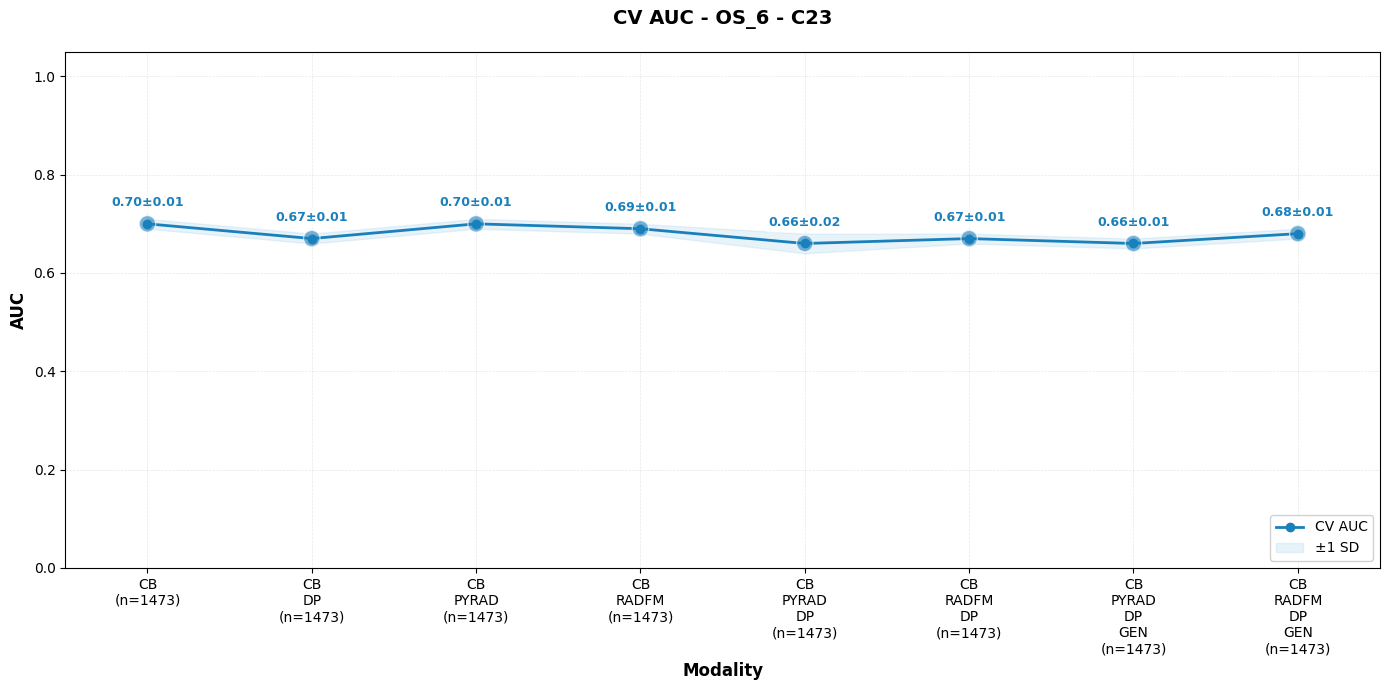

Saved: vanguri_TEST_C23_OS_6.png


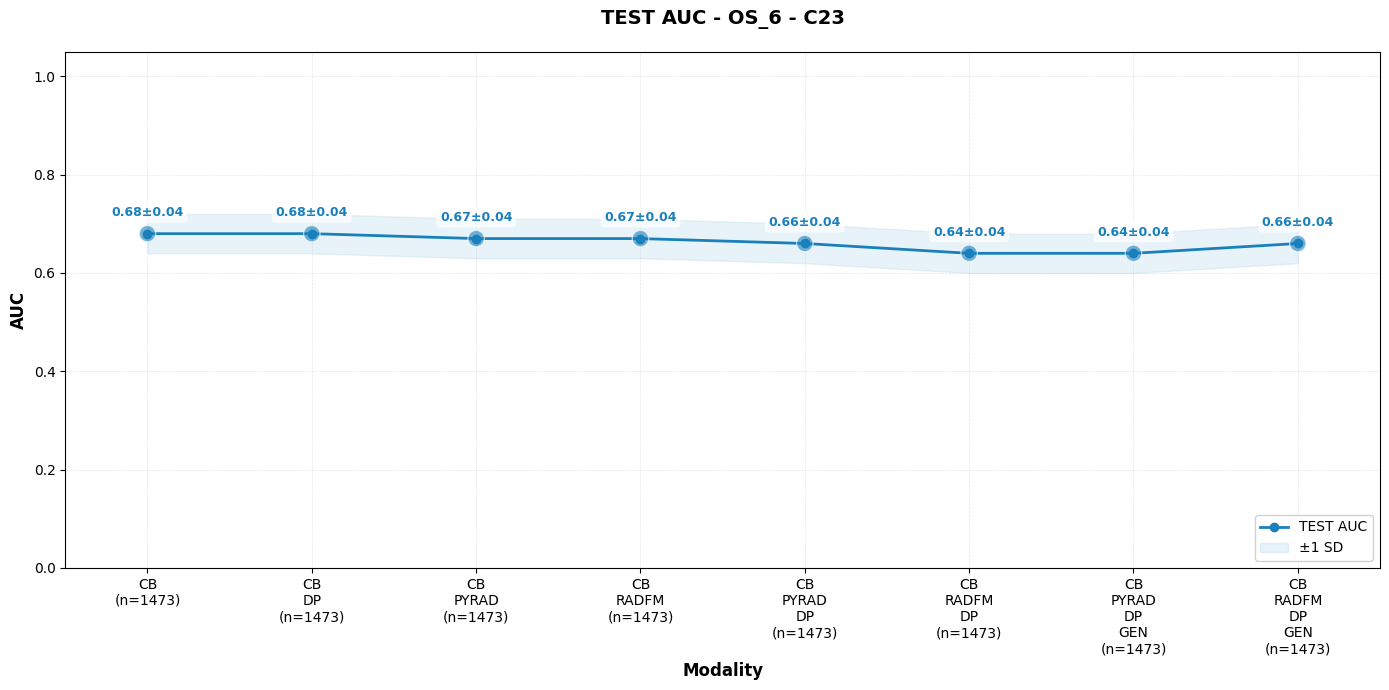

Saved: vanguri_EXT_C23_OS_6.png


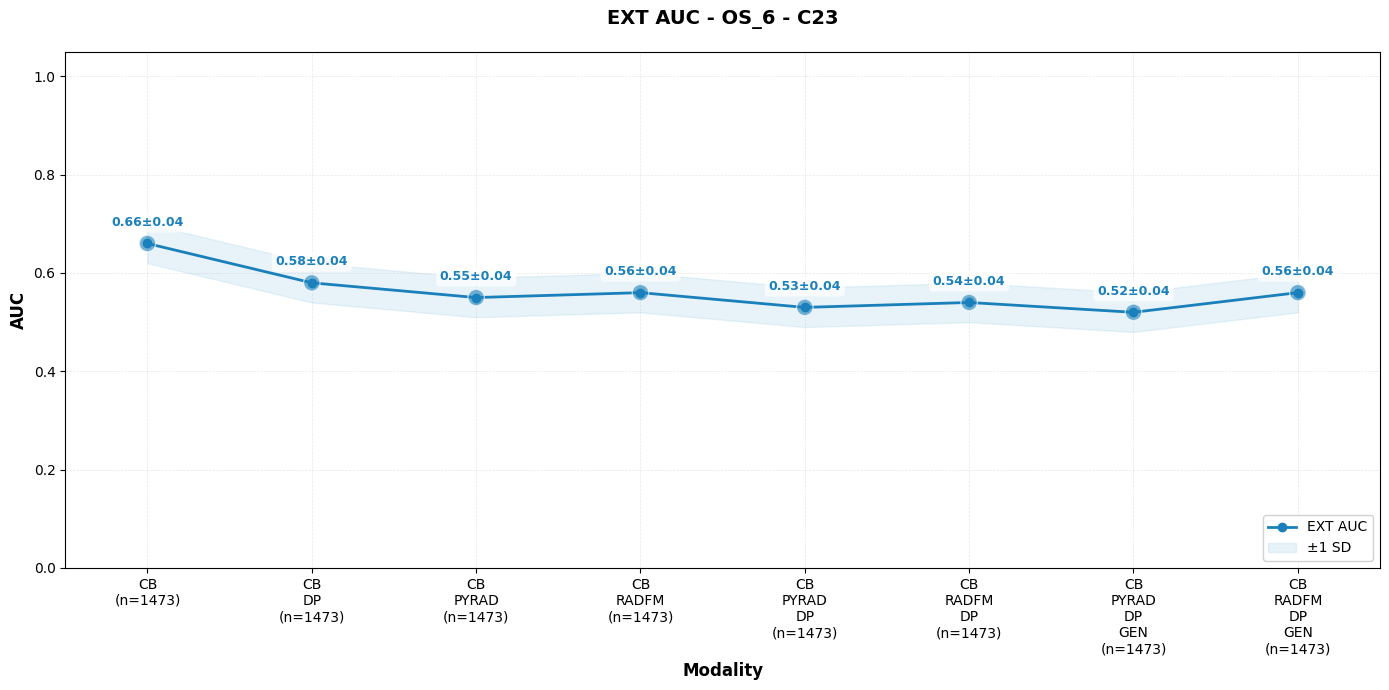

Saved: vanguri_CV_C23_OS_24.png


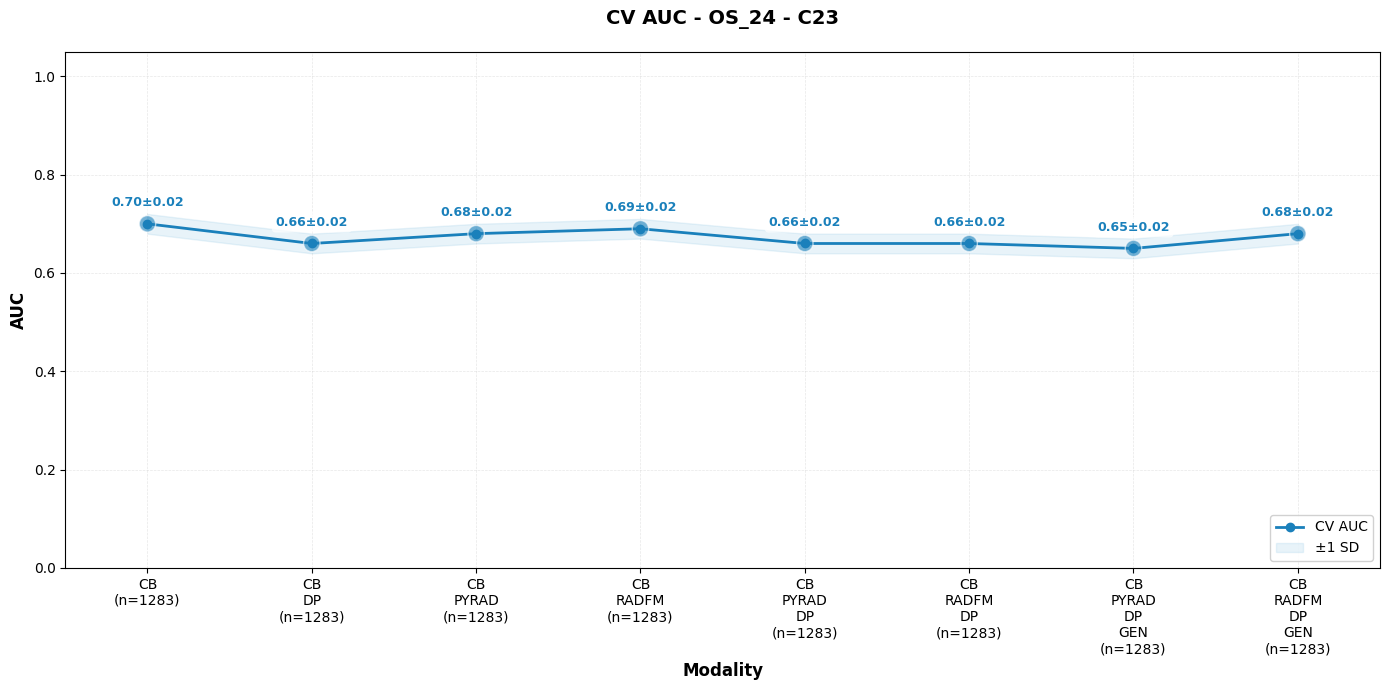

Saved: vanguri_TEST_C23_OS_24.png


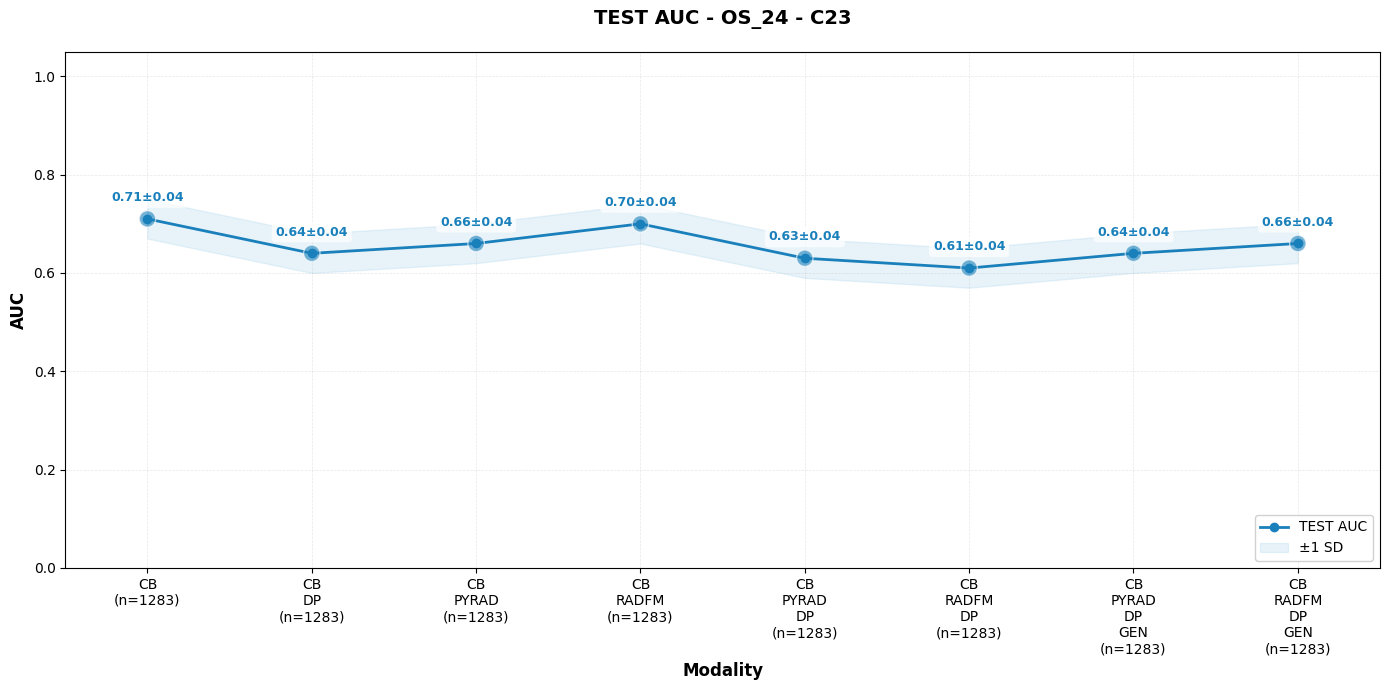

Saved: vanguri_EXT_C23_OS_24.png


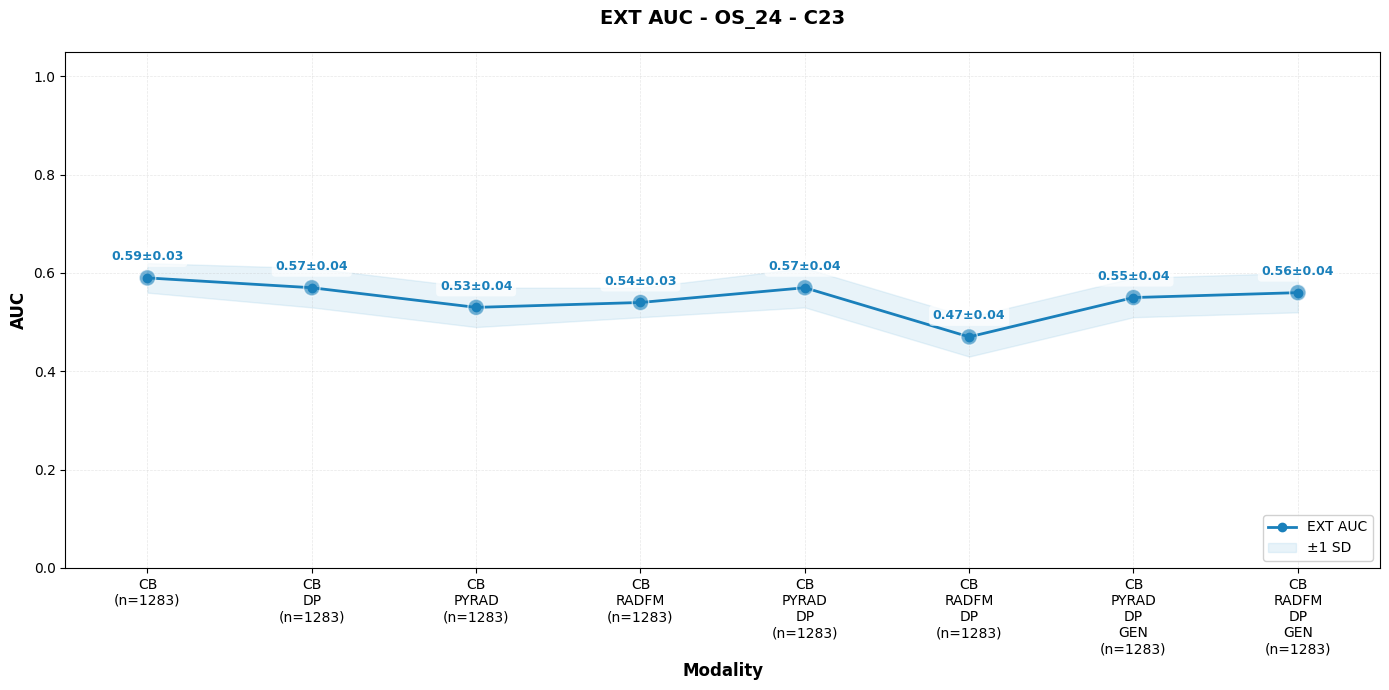

Saved: vanguri_CV_C23_DCR.png


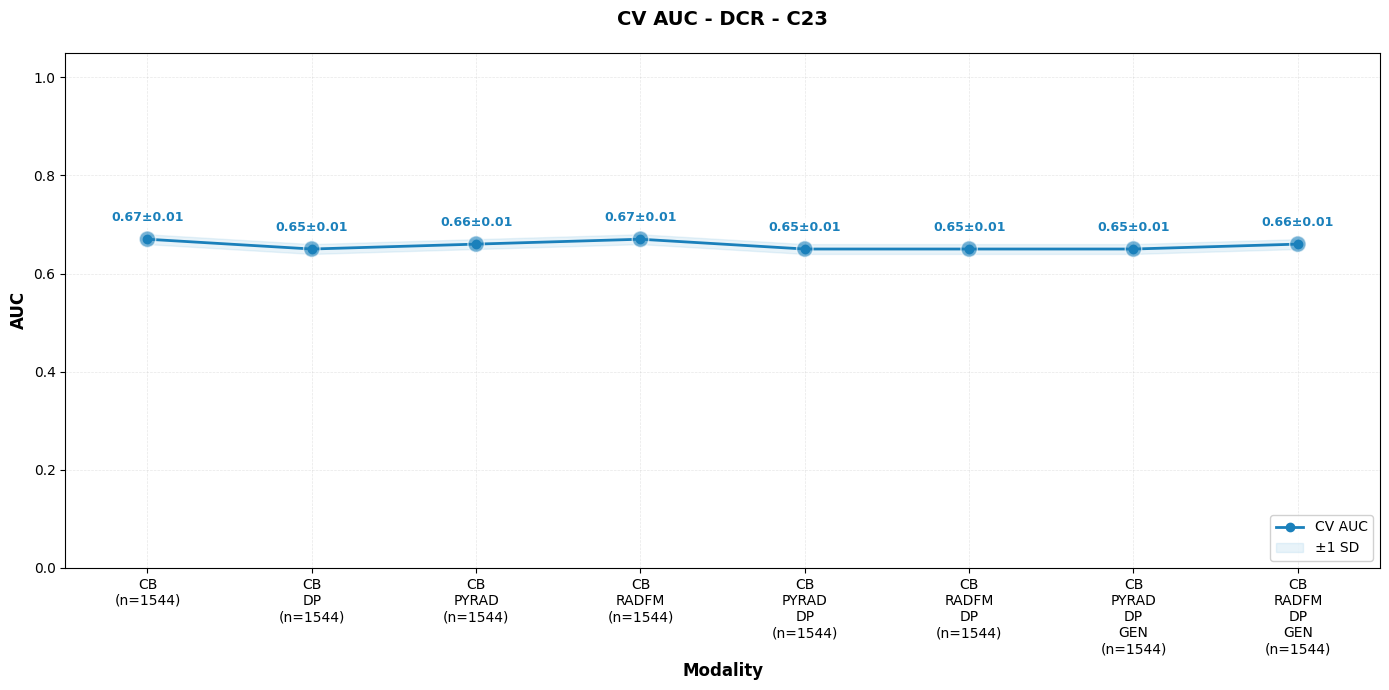

Saved: vanguri_TEST_C23_DCR.png


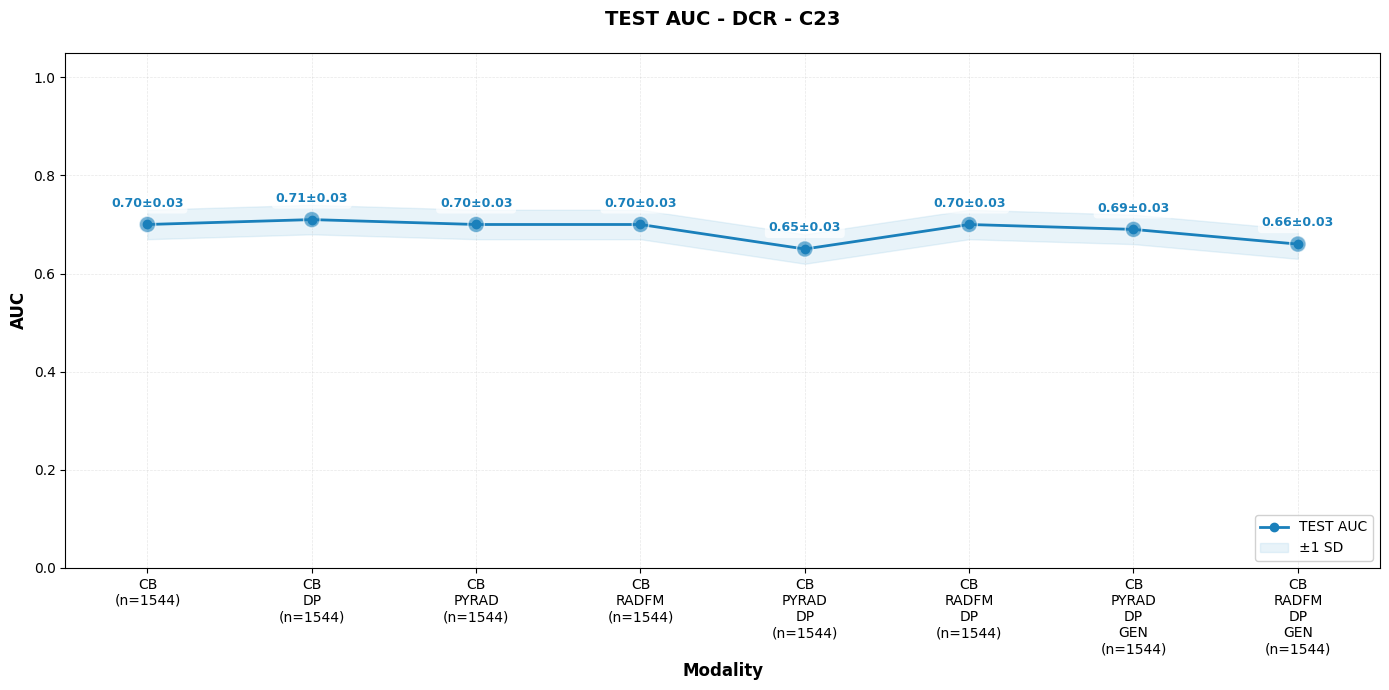

Saved: vanguri_EXT_C23_DCR.png


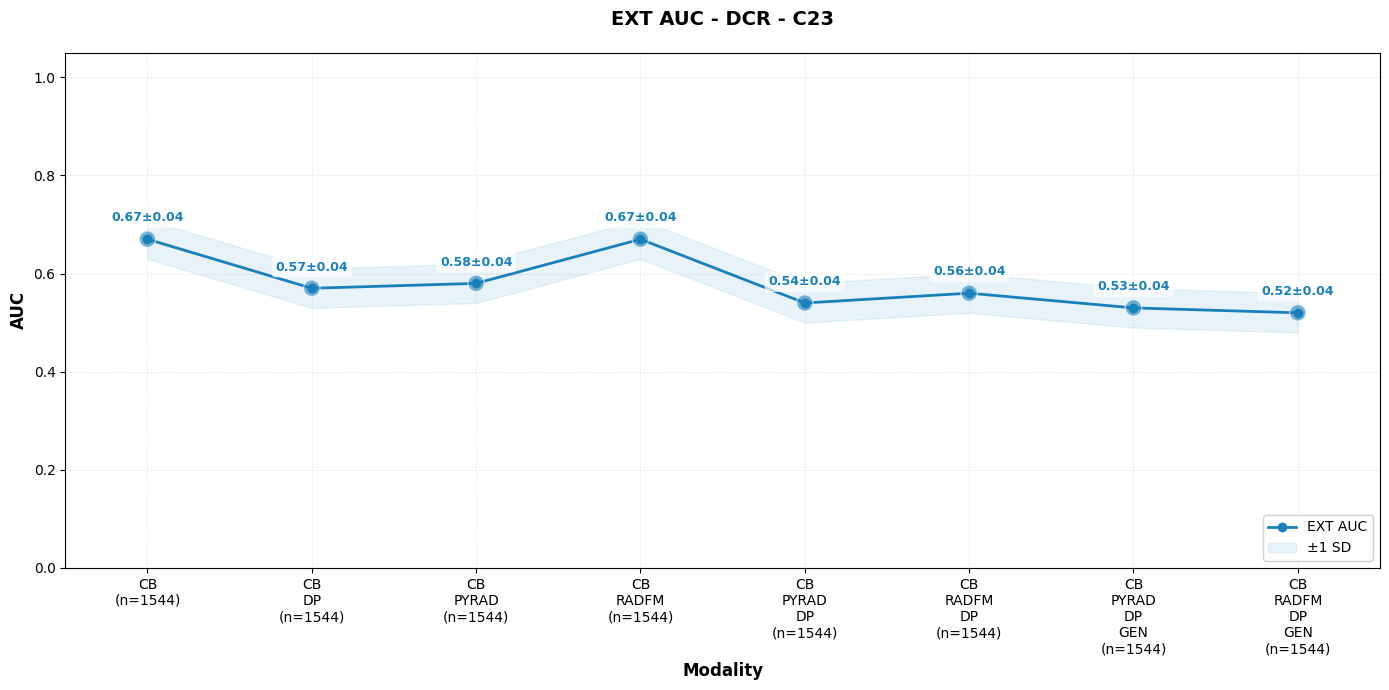

Saved: vanguri_CV_C23_ORR.png


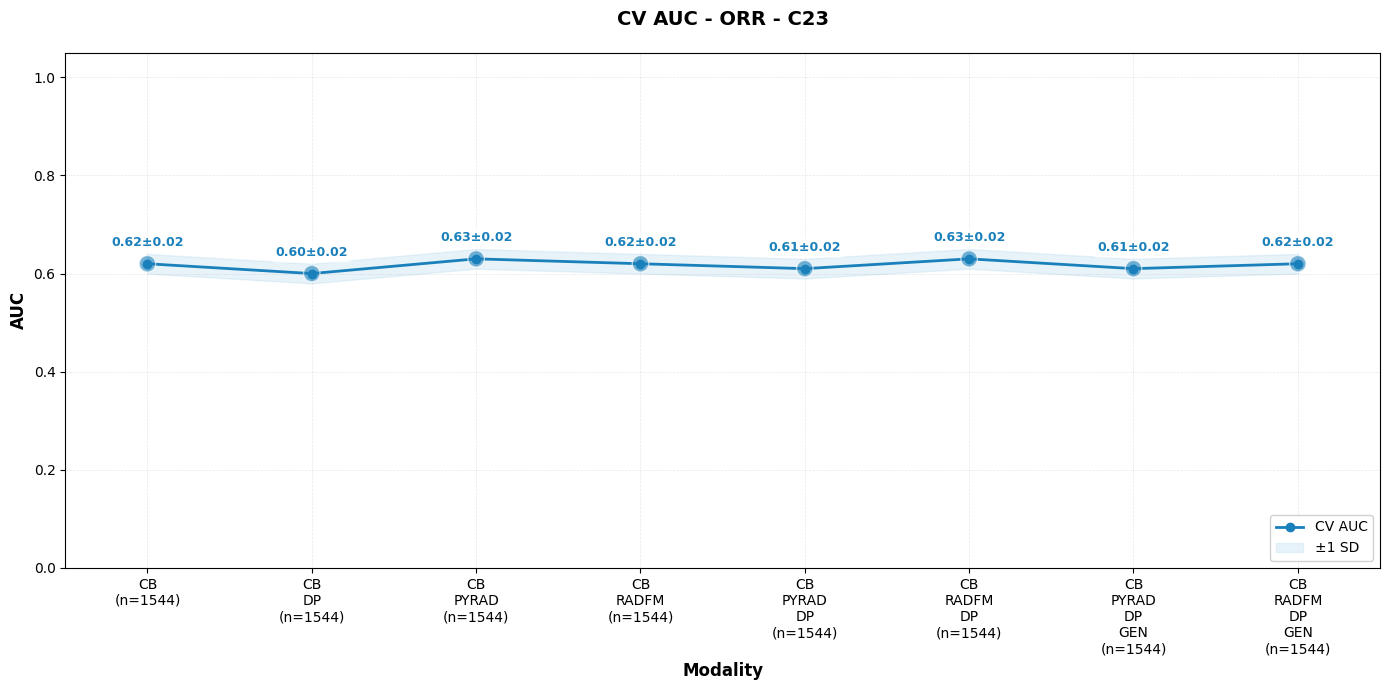

Saved: vanguri_TEST_C23_ORR.png


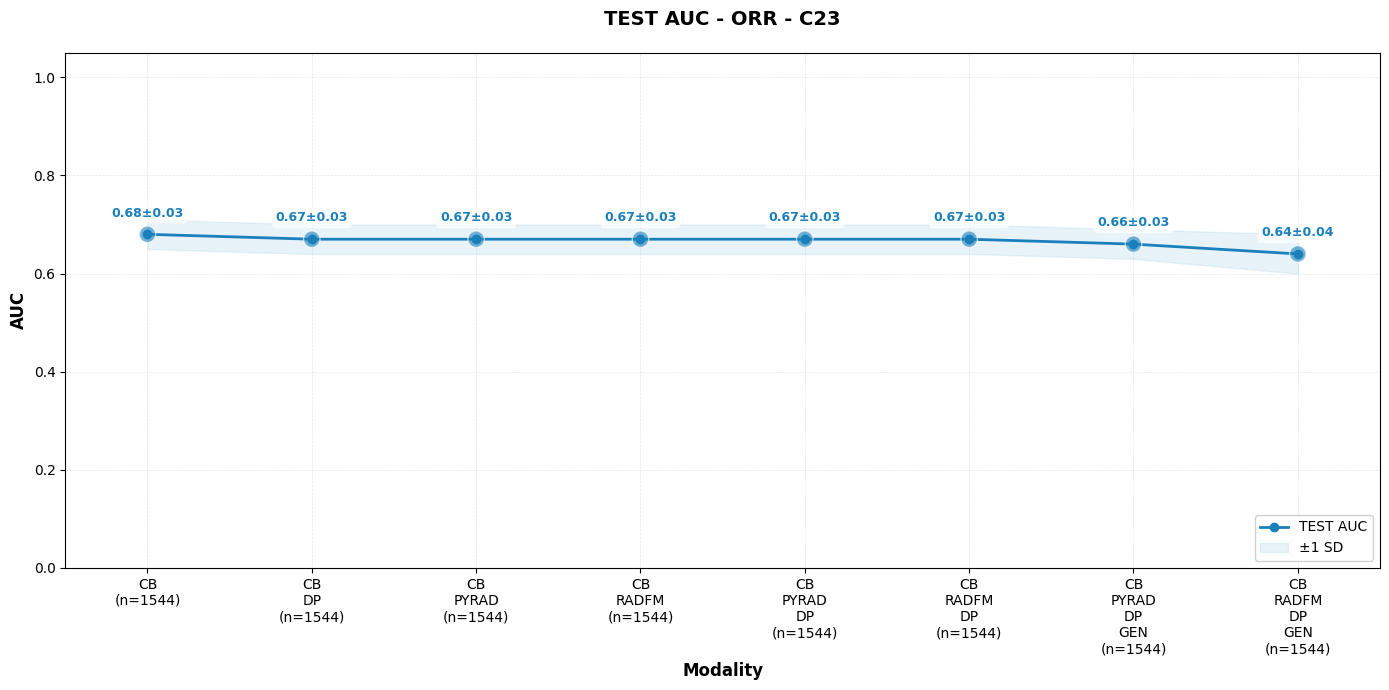

Saved: vanguri_EXT_C23_ORR.png


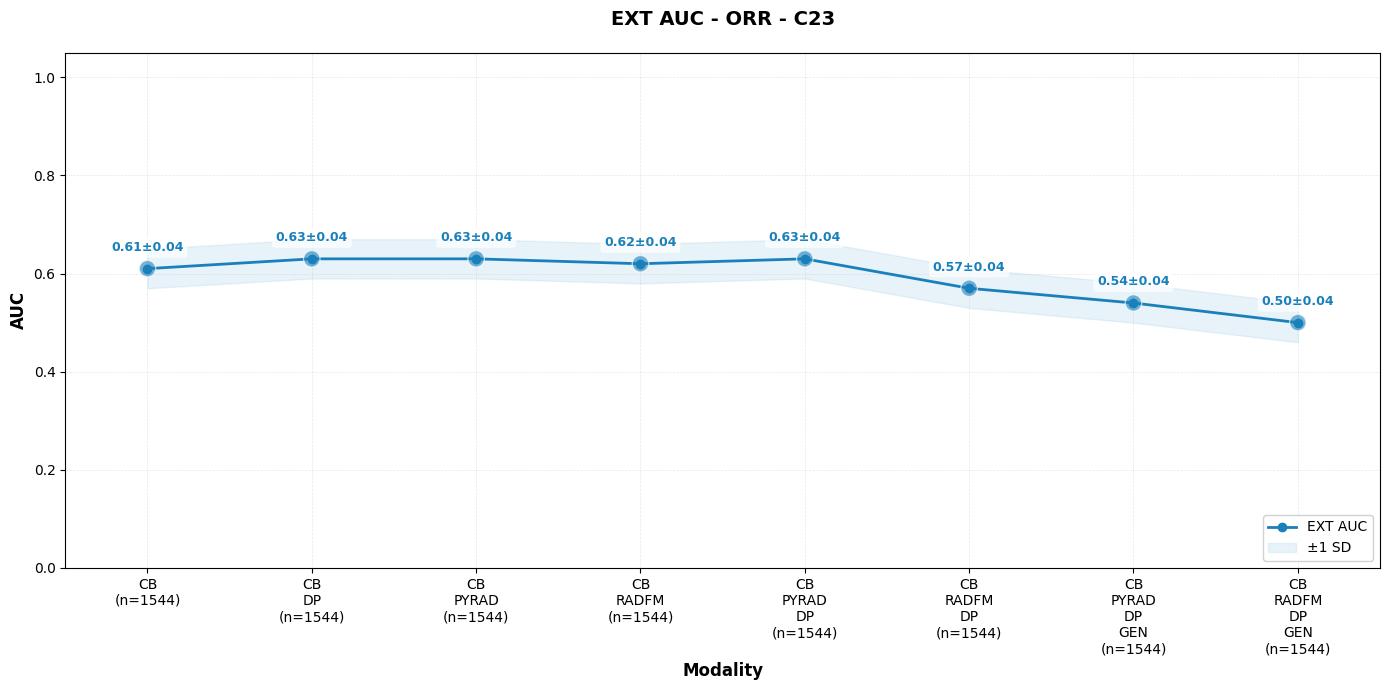

Saved: vanguri_CV_C23_CBR.png


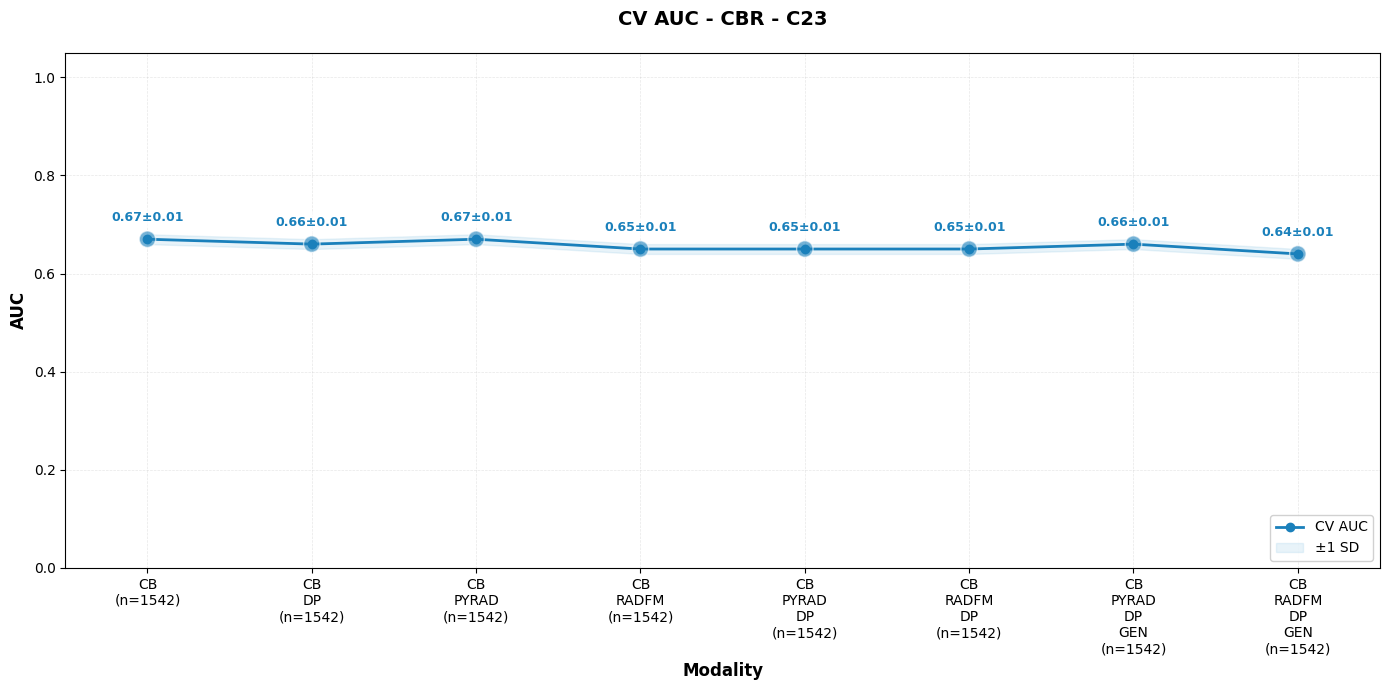

Saved: vanguri_TEST_C23_CBR.png


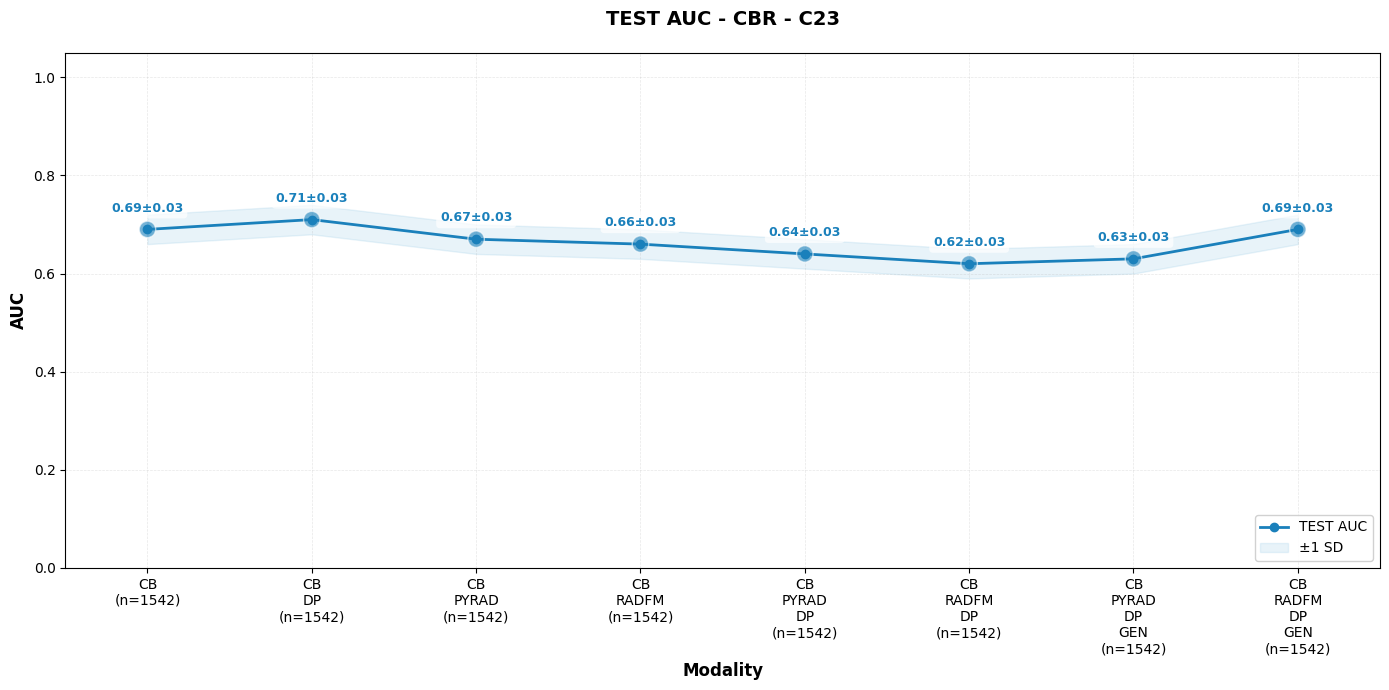

Saved: vanguri_EXT_C23_CBR.png


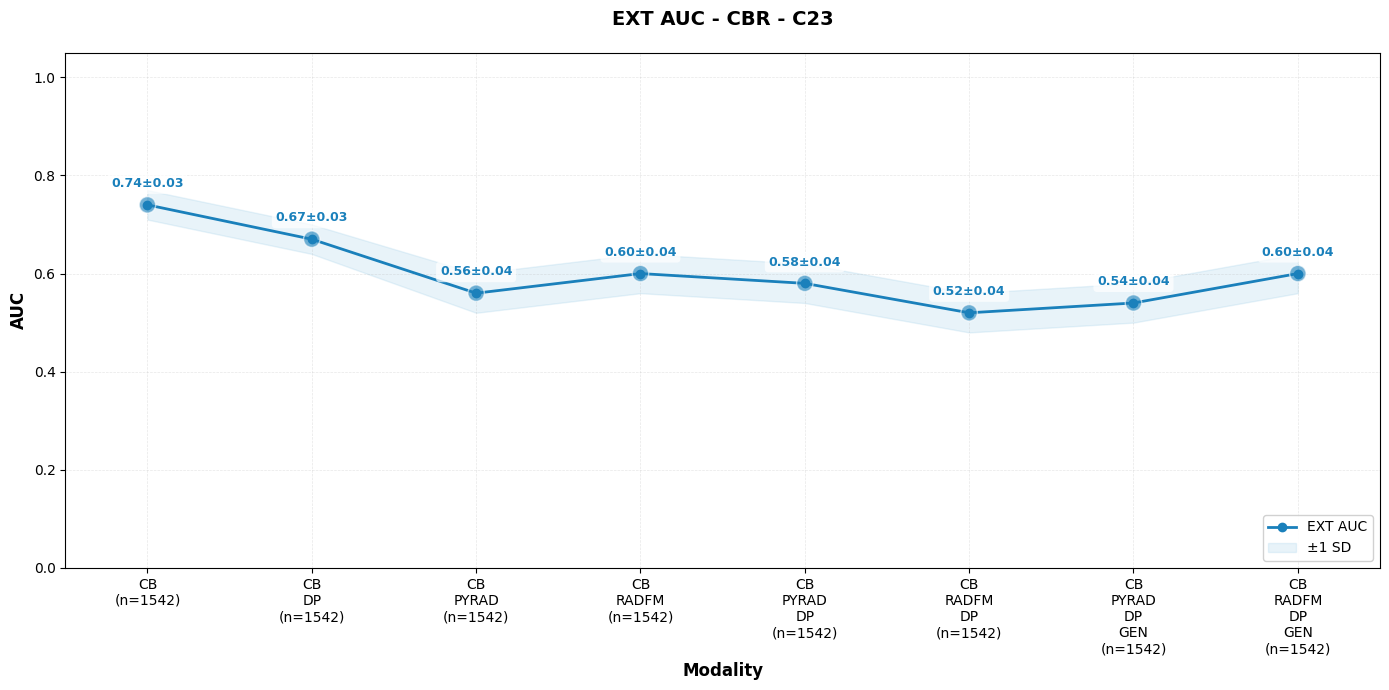

Saved: vanguri_CV_C2_OS_6.png


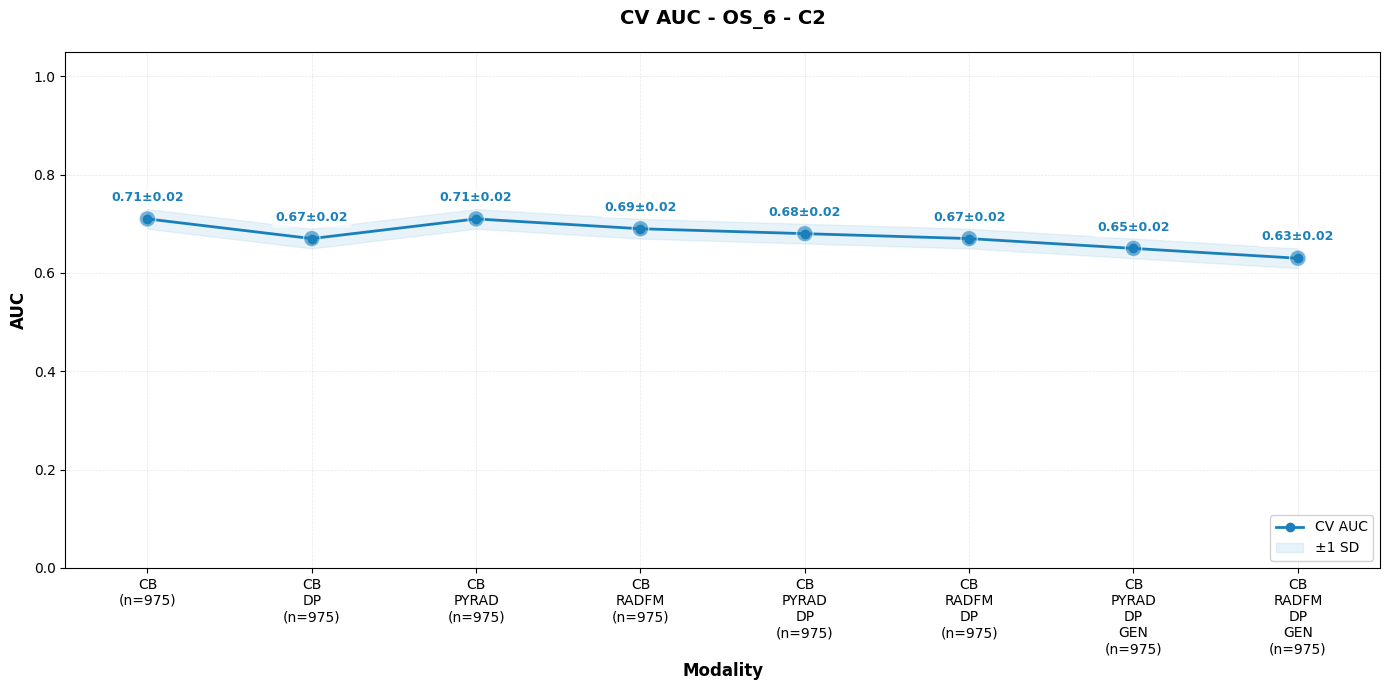

Saved: vanguri_TEST_C2_OS_6.png


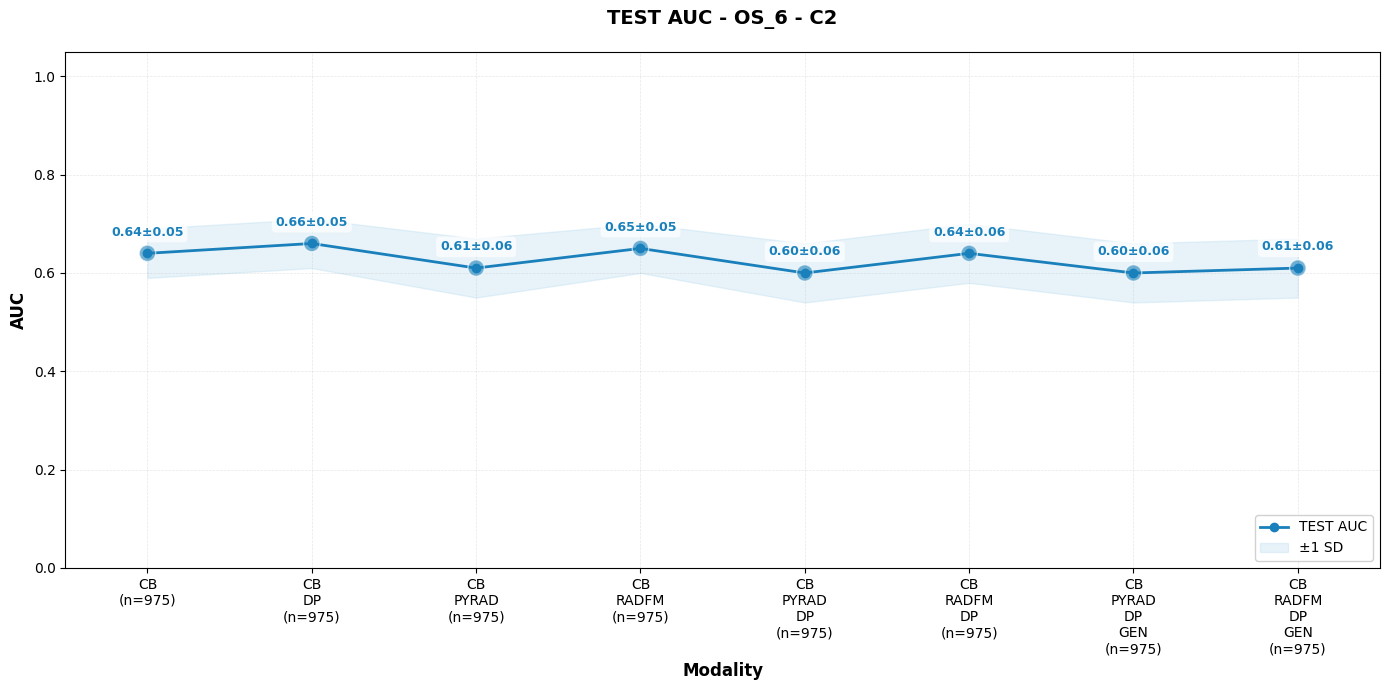

Saved: vanguri_EXT_C2_OS_6.png


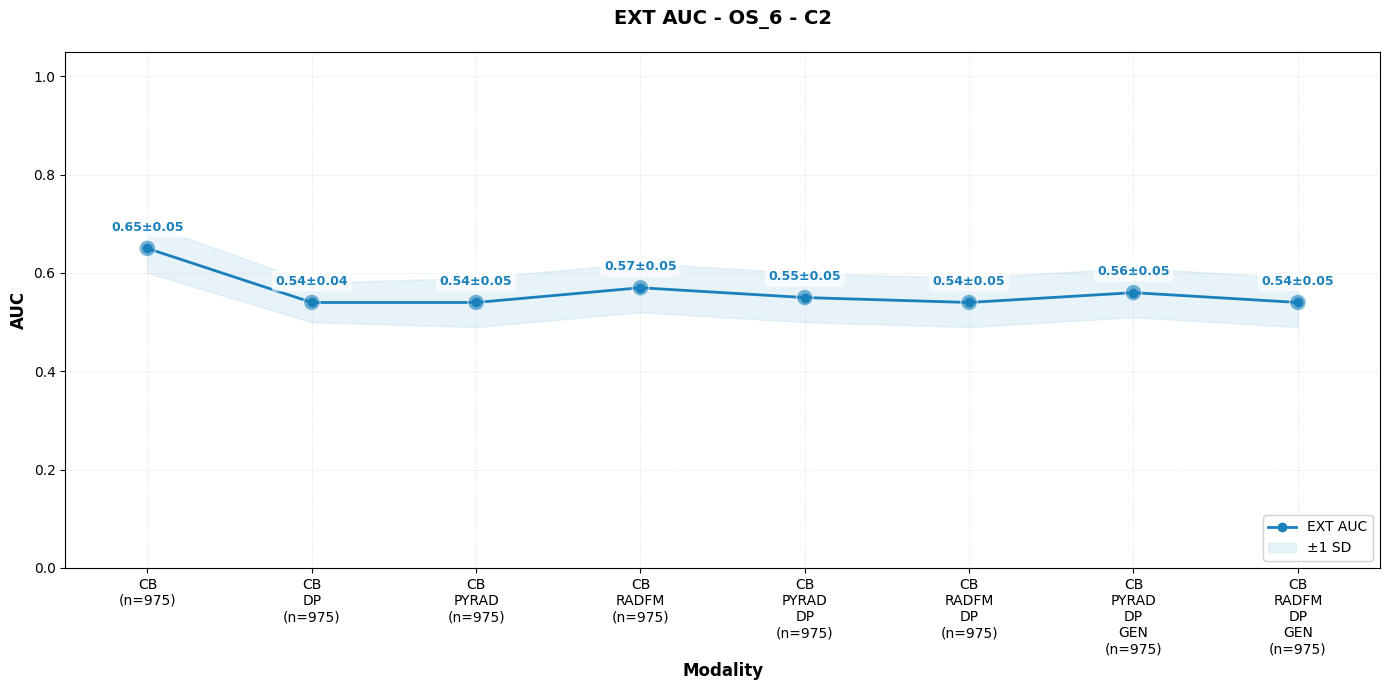

Saved: vanguri_CV_C2_OS_24.png


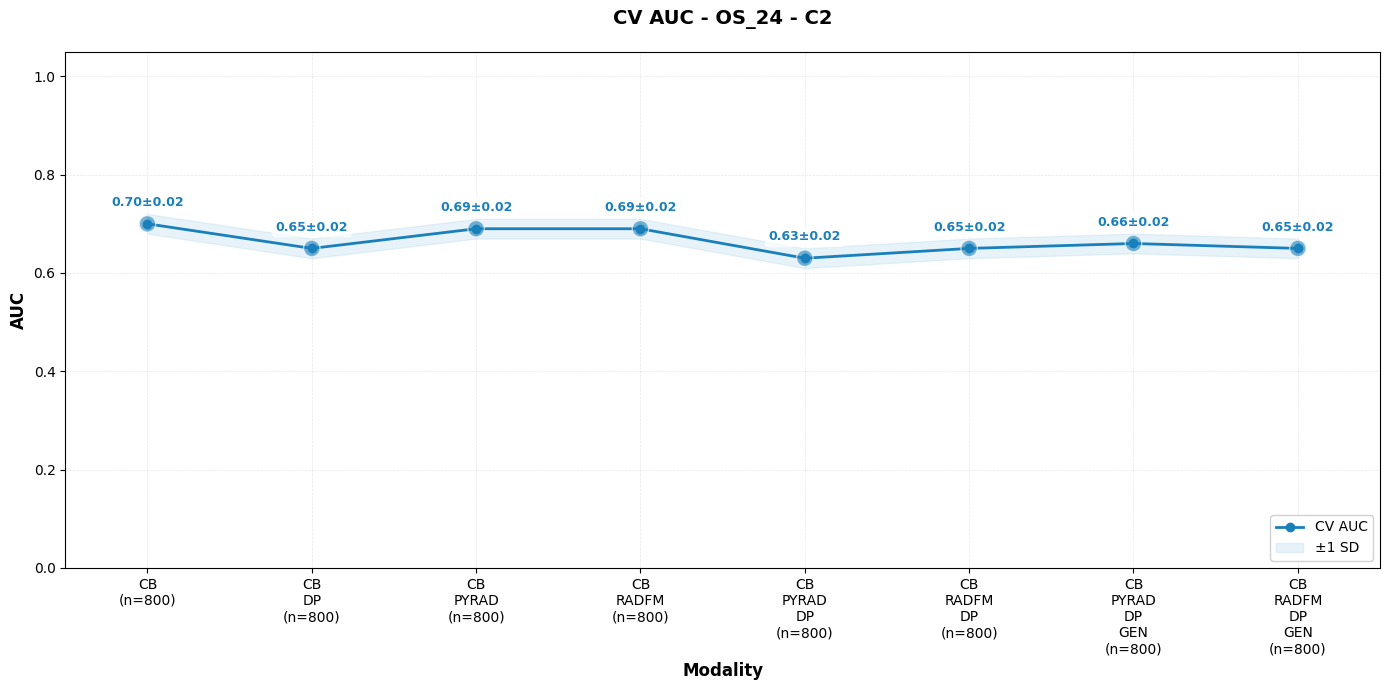

Saved: vanguri_TEST_C2_OS_24.png


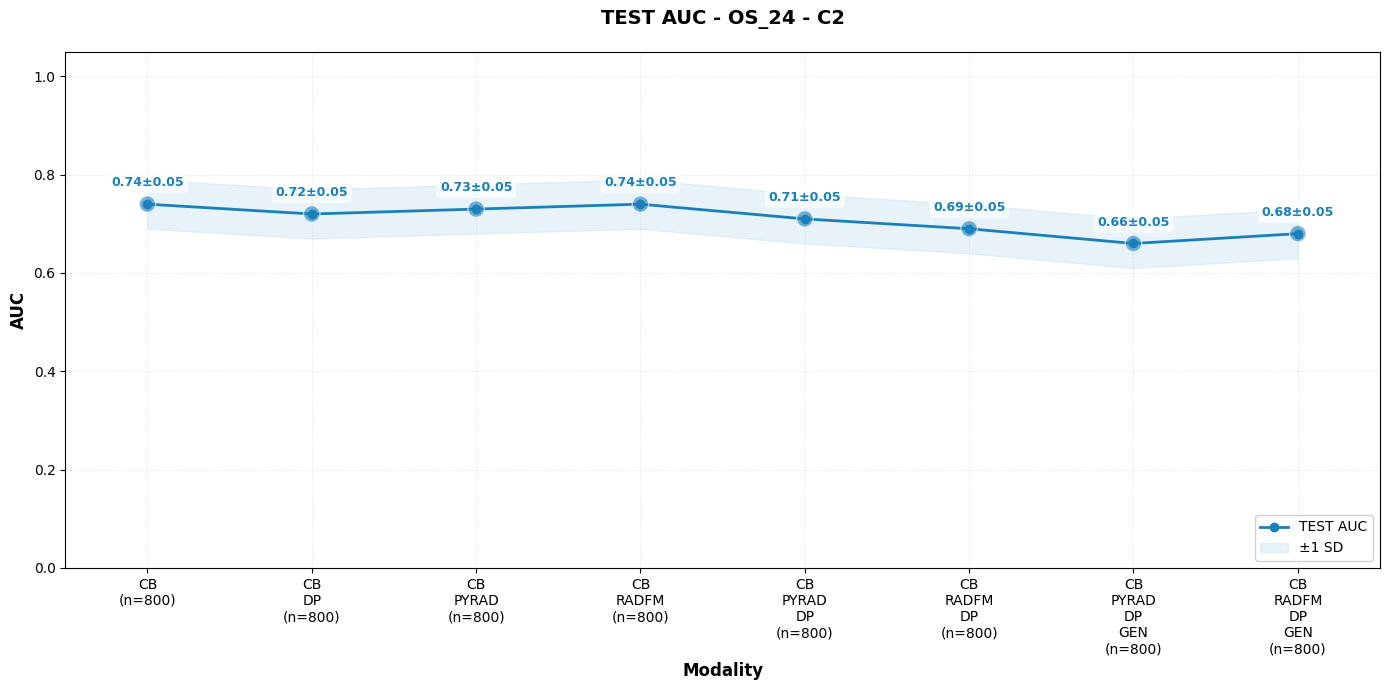

Saved: vanguri_EXT_C2_OS_24.png


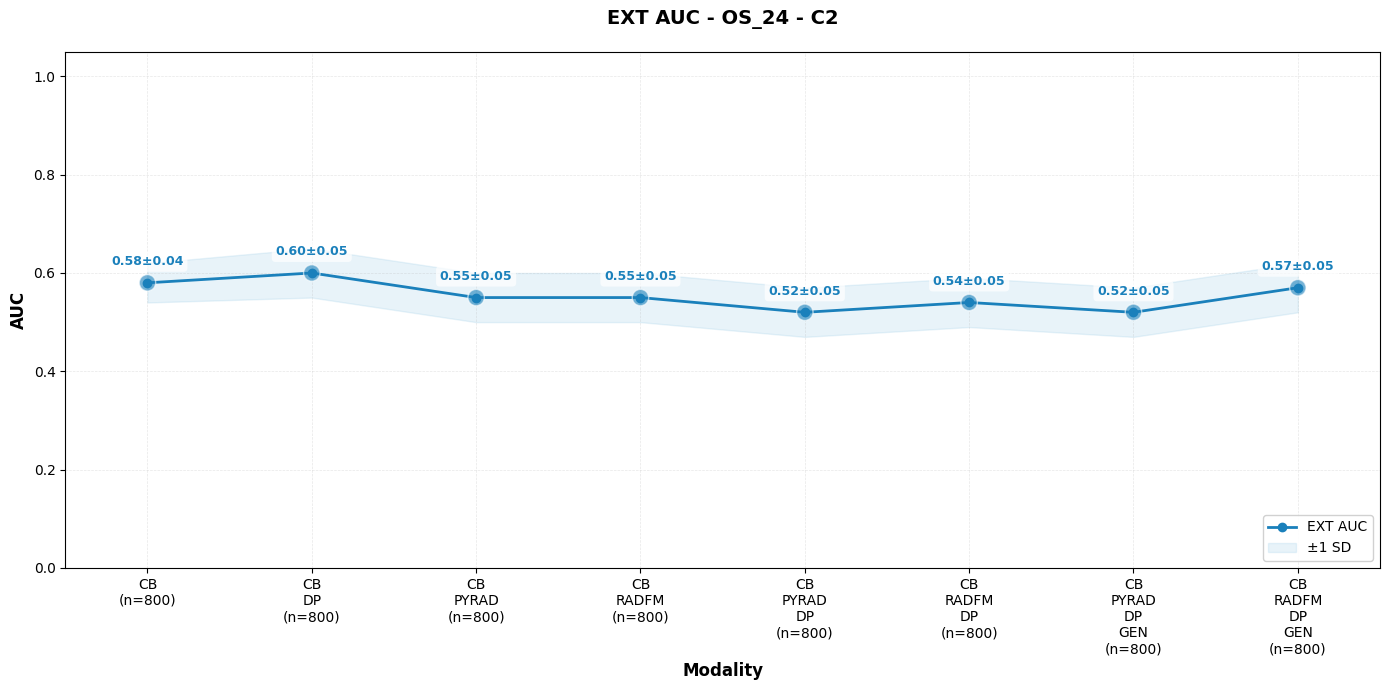

Saved: vanguri_CV_C2_DCR.png


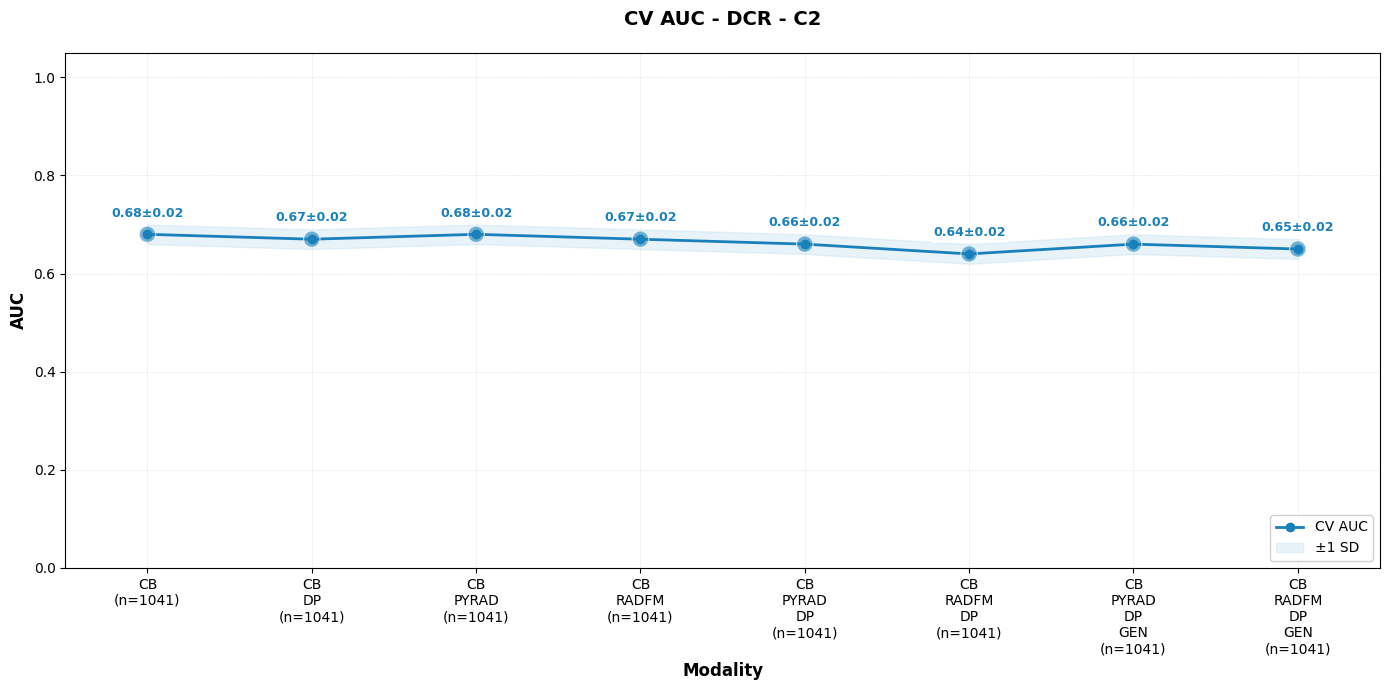

Saved: vanguri_TEST_C2_DCR.png


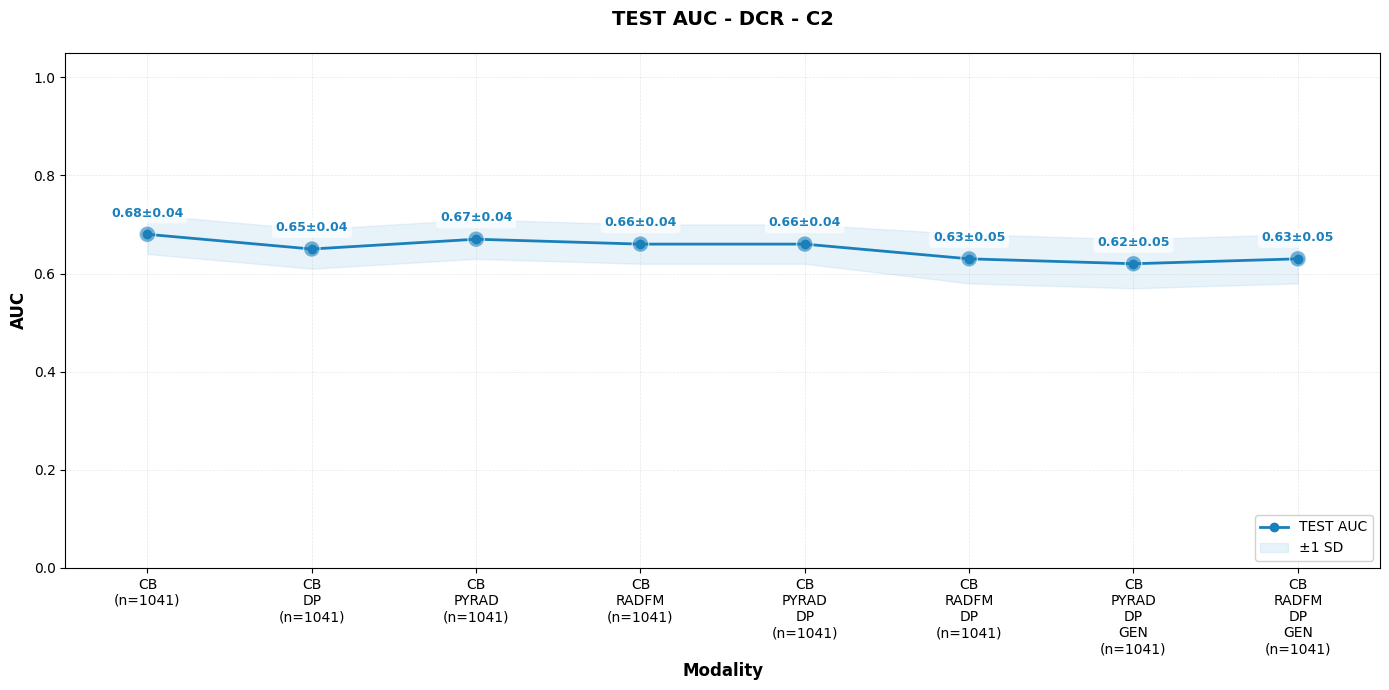

Saved: vanguri_EXT_C2_DCR.png


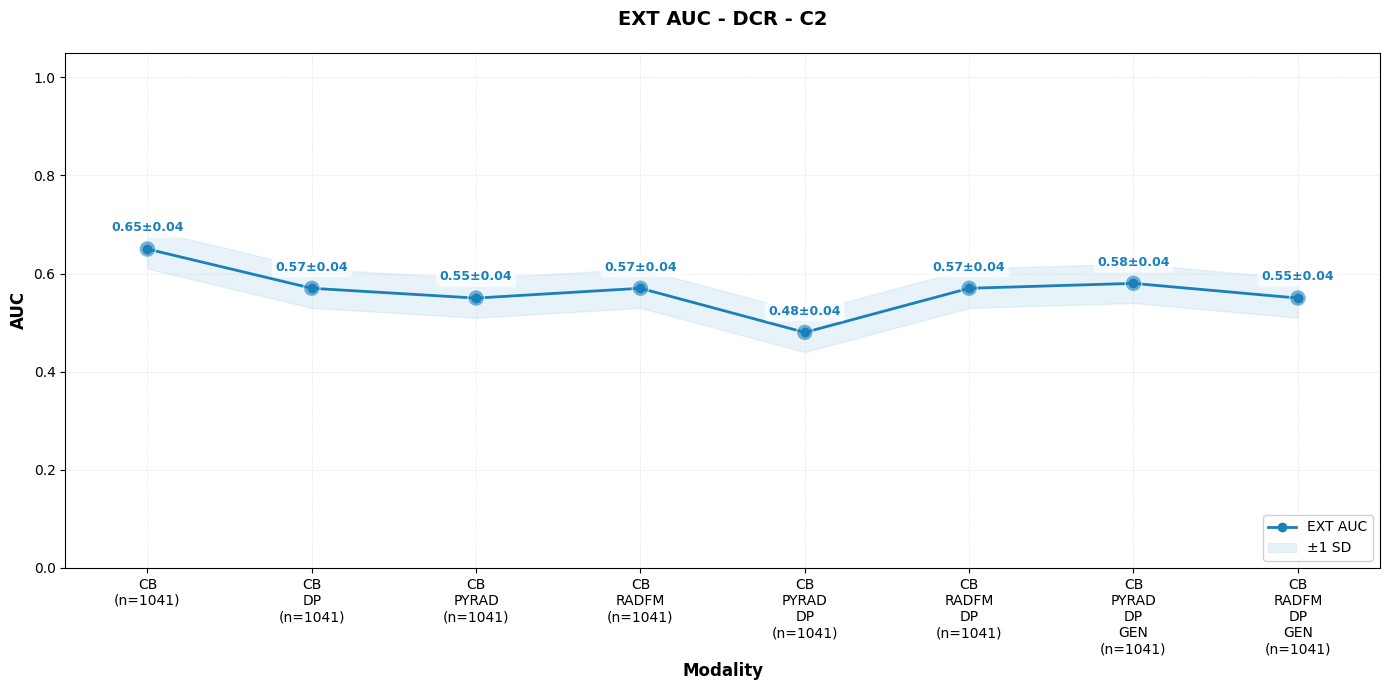

Saved: vanguri_CV_C2_ORR.png


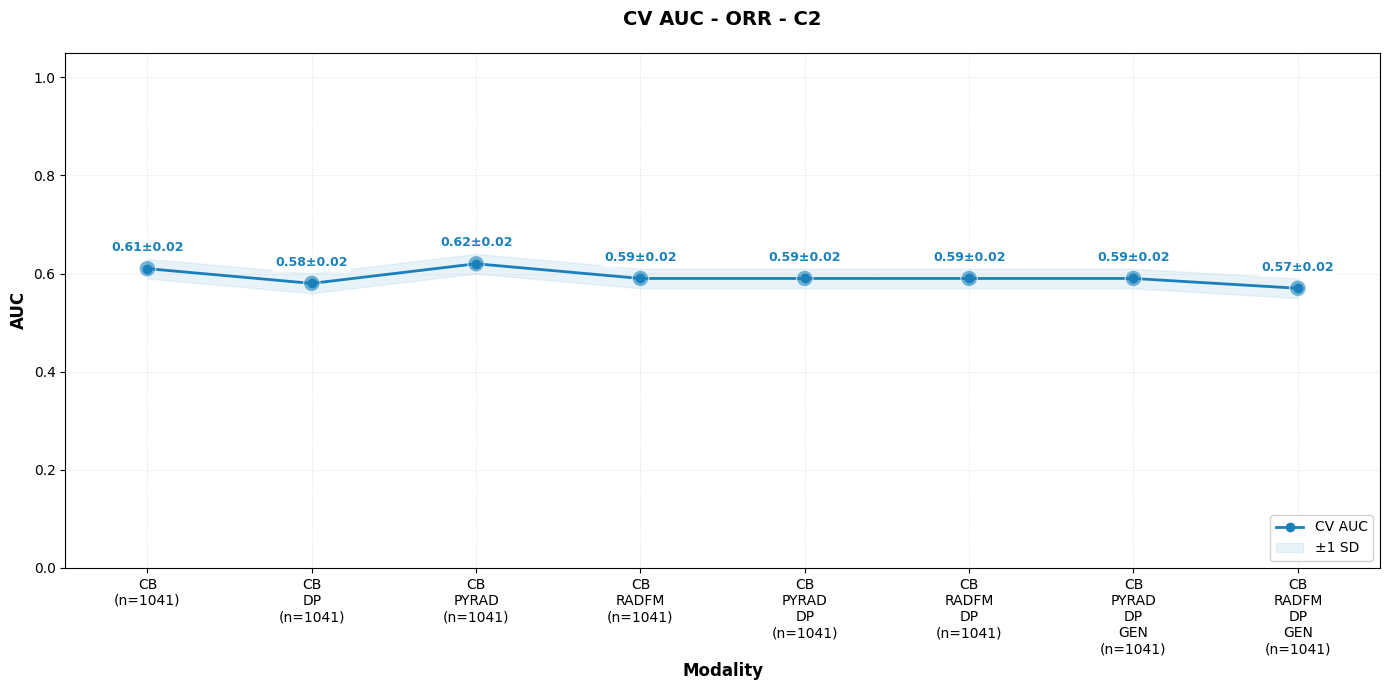

Saved: vanguri_TEST_C2_ORR.png


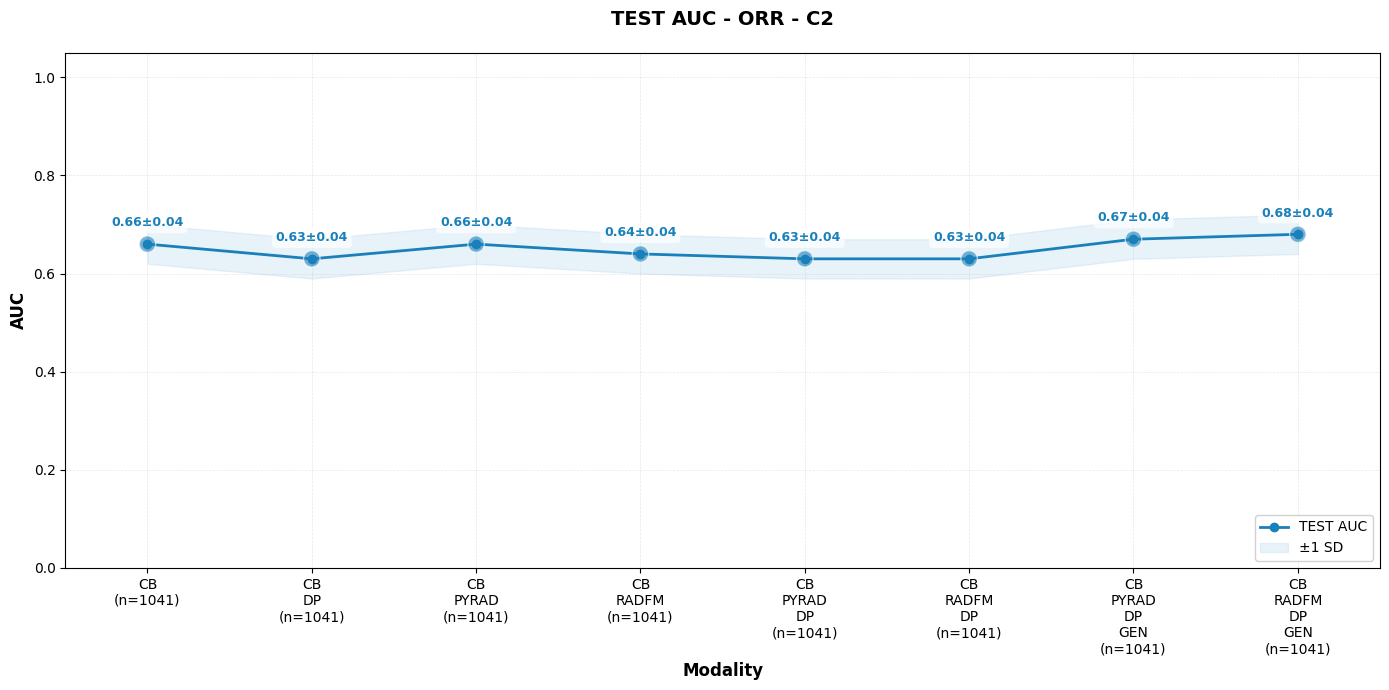

Saved: vanguri_EXT_C2_ORR.png


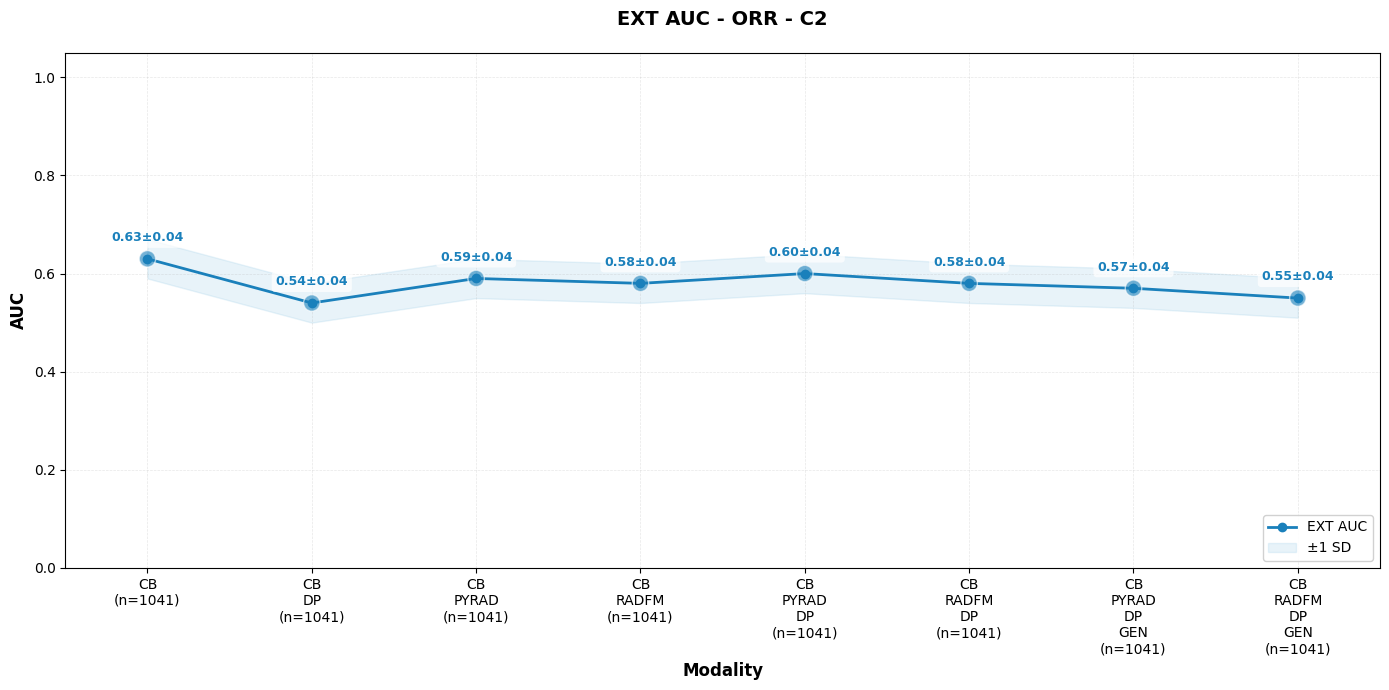

Saved: vanguri_CV_C2_CBR.png


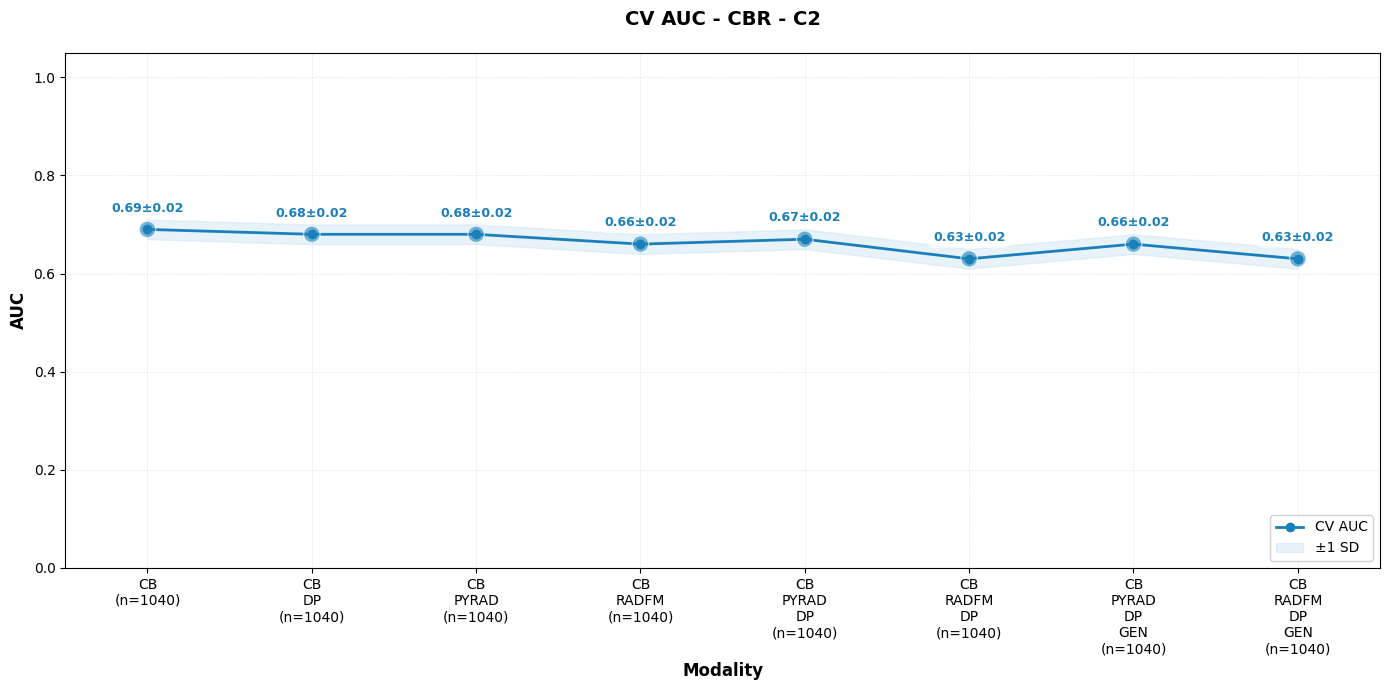

Saved: vanguri_TEST_C2_CBR.png


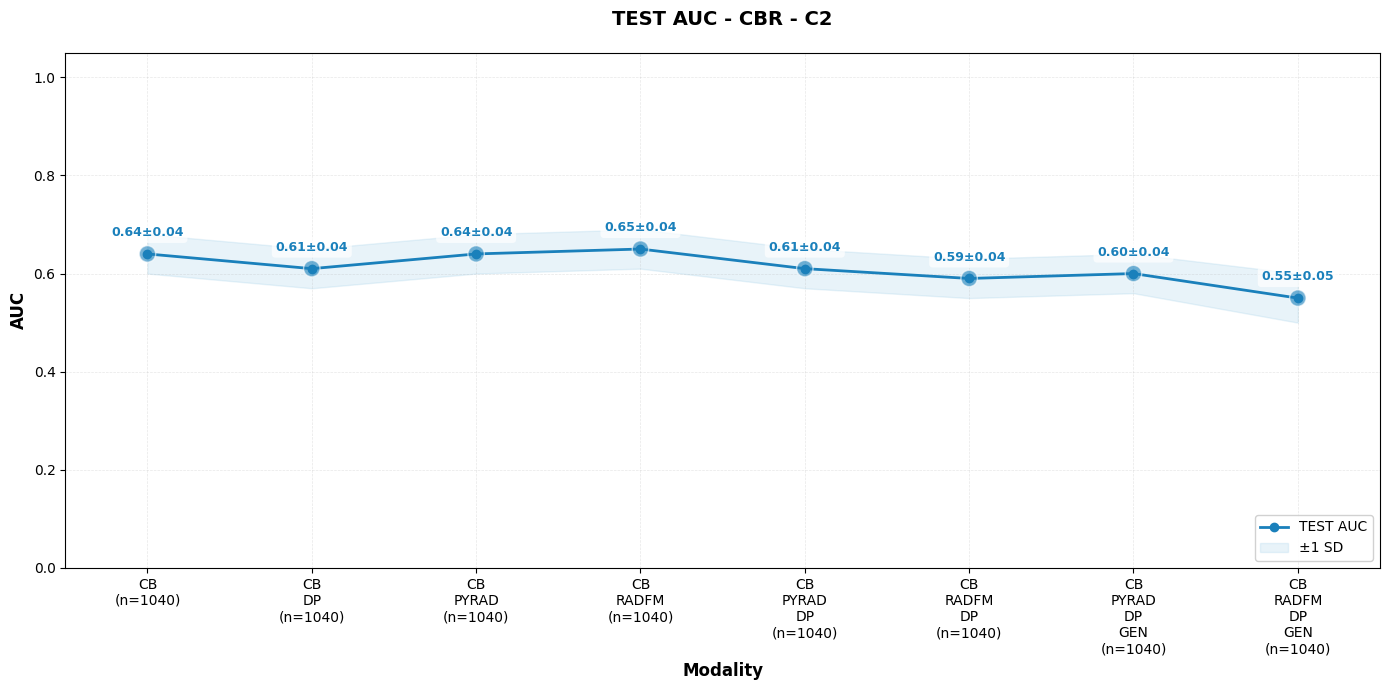

Saved: vanguri_EXT_C2_CBR.png


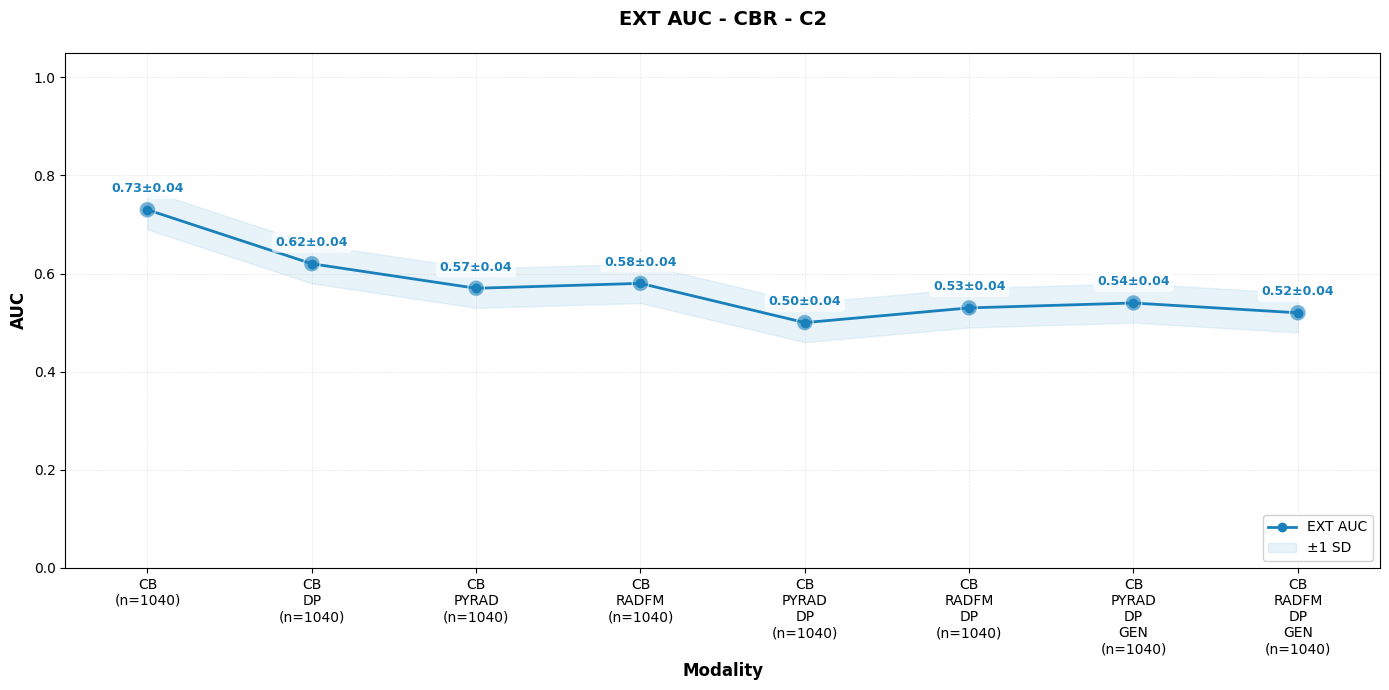


All plots saved to: results/plots


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def plot_vanguri_results(summary_xlsx='results/summary_all_results.xlsx', output_dir='results/plots',
                         min_bubble=30, max_bubble=250, show=True):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    df = pd.read_excel(summary_xlsx)

    modality_order = ['RWD-only', 'RWD_DP', 'RWD_PYRAD', 'RWD_RADFM',
                      'RWD_PYRAD_DP', 'RWD_RADFM_DP',
                      'RWD_PYRAD_DP_GEN', 'RWD_RADFM_DP_GEN']

    def _parse_auc(val):
        if pd.isna(val) or val == '':
            return np.nan, np.nan
        s = str(val).replace('+/-', '±')
        parts = [p.strip() for p in s.split('±')]
        try:
            return float(parts[0]), float(parts[1]) if len(parts) == 2 else 0.0
        except:
            return np.nan, np.nan

    def _scale_sizes(raw):
        arr = np.array(raw, dtype=float)
        if np.all(np.isnan(arr)):
            return np.full(arr.shape, (min_bubble + max_bubble) / 2)
        amin, amax = np.nanmin(arr), np.nanmax(arr)
        if amax - amin < 1e-9:
            return np.full(arr.shape, (min_bubble + max_bubble) / 2)
        norm = (arr - amin) / (amax - amin + 1e-6)
        scaled = norm * (max_bubble - min_bubble) + min_bubble
        scaled[np.isnan(scaled)] = (min_bubble + max_bubble) / 2
        return scaled

    for analysis in df['ANALYSIS'].unique():
        for outcome in df['OUTCOME'].unique():
            subset = df[(df['ANALYSIS'] == analysis) & (df['OUTCOME'] == outcome)]
            if subset.empty:
                continue

            # Order modalities
            subset = subset.set_index('MODALITY').reindex(modality_order).dropna(how='all').reset_index()
            if subset.empty:
                continue

            # Parse n_train
            n_trains = pd.to_numeric(subset['n. train'], errors='coerce').values

            for set_type, auc_col, label in [
                ('CV', 'CV-AUC/CINDEX', 'CV AUC'),
                ('TEST', 'TEST-AUC/CINDEX', 'TEST AUC'),
                ('EXT', 'EXT-AUC/CINDEX', 'EXT AUC'),
            ]:
                parsed = [_parse_auc(v) for v in subset[auc_col]]
                means = np.array([p[0] for p in parsed])
                stds = np.array([p[1] for p in parsed])

                # Skip if all NaN
                if np.all(np.isnan(means)):
                    continue

                modalities = subset['MODALITY'].values
                X = np.arange(len(modalities))
                sizes = _scale_sizes(n_trains)

                # NUOVO: stile DLIF - figura più grande e proporzioni diverse
                fig = plt.figure(figsize=(14, 7))
                
                # Line plot + scatter con bubble
                plt.plot(X, means, linestyle='-', marker='o', label=label, color='#1a80bb', linewidth=2)
                plt.scatter(X, means, s=sizes, color='#1a80bb', alpha=0.6, zorder=3, edgecolors='white', linewidths=1)
                
                # Confidence interval
                plt.fill_between(X, means - stds, means + stds,
                                 alpha=0.2, color='#8cc5e3', label='±1 SD')

                # X tick labels (multiline + n_train)
                xticks = []
                for m, n in zip(modalities, n_trains):
                    parts = m.replace('RWD-only', 'CB').replace('RWD', 'CB').split('_')
                    formatted = '\n'.join(parts)
                    n_str = int(n) if np.isfinite(n) else 'NA'
                    xticks.append(f"{formatted}\n(n={n_str})")
                plt.xticks(X, xticks, rotation=0, fontsize=10)

                # Value annotations - NUOVO: spostate sopra i punti
                for i, (mval, mstd) in enumerate(zip(means, stds)):
                    if np.isfinite(mval):
                        # Posiziona sopra il punto invece che in basso
                        y_offset = 0.03
                        plt.text(i, mval + y_offset, f"{mval:.2f}±{mstd:.2f}",
                                 fontsize=9, ha='center', va='bottom', 
                                 color='#1a80bb', fontweight='bold',
                                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                          edgecolor='none', alpha=0.7))

                # NUOVO: titolo più pulito e professionale
                plt.title(f"{label} - {outcome} - {analysis}", 
                         fontsize=14, fontweight='bold', pad=20)
                plt.ylabel('AUC', fontsize=12, fontweight='bold')
                plt.xlabel('Modality', fontsize=12, fontweight='bold')
                
                # NUOVO: ylim con margine superiore per le annotazioni
                plt.ylim(0, 1.05)
                
                # Grid più leggera
                plt.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
                
                # Legend più elegante
                plt.legend(fontsize=10, framealpha=0.9, loc='lower right')
                
                # NUOVO: xlim con margini simmetrici
                plt.xlim(-0.5, len(modalities) - 0.5)
                
                # NUOVO: layout tight per evitare tagli
                plt.tight_layout()

                fname = f"vanguri_{set_type}_{analysis}_{outcome}.png"
                plt.savefig(output_dir / fname, dpi=300, bbox_inches='tight', facecolor='white')
                print(f"Saved: {fname}")
                if show:
                    plt.show()
                plt.close()

    print(f"\nAll plots saved to: {output_dir}")


if __name__ == "__main__":
    plot_vanguri_results()